# Case SENTINEL — Stage 1: Baseline Surveillance Validation
**DECODE X | NLD Synapse 2026**

Pipeline: Data Load → Graph Construction → Loop Detection → Suspect Validation → Mechanism Classification → Network Analysis → Risk Scoring → Entity Expansion

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import glob
import os
import ast
import warnings
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('future.no_silent_downcasting', True)

# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────
TRADES_CSV      = r'E:\Synapse-BI\04 – Case SENTINEL\master_trades_combined.csv'
SUSPECT_FOLDER  = r'E:\Synapse-BI\04 – Case SENTINEL\Suspicious list\Trades'

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1A — LOAD TRADES
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(TRADES_CSV, low_memory=False)

# Normalise the split Sell Client Code column
if 'Sell Client code' in df.columns:
    df['Sell Client Code'] = df['Sell Client Code'].fillna(df['Sell Client code'])
df.drop(columns=[c for c in ['Sell Client code', 'Buy Timestamp', 'Sell Timestamp']
                 if c in df.columns], inplace=True)

# Standardise key column types
df['SCRIP_CODE']       = df['SCRIP_CODE'].astype(str).str.strip()
df['Buy Client Code']  = df['Buy Client Code'].astype(str).str.strip()
df['Sell Client Code'] = df['Sell Client Code'].astype(str).str.strip()
df['BUY_MEMBER_CODE']  = df['BUY_MEMBER_CODE'].astype(str).str.strip()
df['SELL_MEMBER_CODE'] = df['SELL_MEMBER_CODE'].astype(str).str.strip()
df['TRADE_TIME_DT']    = pd.to_datetime(df['TRADE_TIME'], errors='coerce', format='mixed')

print(f"Trades loaded: {len(df):,} rows | {df['SCRIP_CODE'].nunique()} scrips | "
      f"{df['TRADE_DATE'].nunique()} dates")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1B — LOAD SUSPECT LISTS
# ─────────────────────────────────────────────────────────────────────────────
suspect_files = glob.glob(os.path.join(SUSPECT_FOLDER, '*.csv'))
suspects_raw = []
for f in suspect_files:
    try:
        tmp = pd.read_csv(f)
        if not tmp.empty:
            suspects_raw.append(tmp)
    except Exception:
        pass

suspects_df = pd.concat(suspects_raw, ignore_index=True)
suspects_df.columns = suspects_df.columns.str.strip()
suspects_df['client_id']   = suspects_df['client_id'].astype(str).str.strip()
suspects_df['scrip_code']  = suspects_df['scrip_code'].astype(str).str.strip()
suspects_df['member_code'] = suspects_df['member_code'].astype(str).str.strip()

print(f"Suspect list loaded: {len(suspects_df):,} rows | "
      f"{suspects_df['client_id'].nunique():,} unique clients")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1C — BUILD GRAPHS
# ─────────────────────────────────────────────────────────────────────────────
# Bipartite: Member ↔ Client
B_graph = nx.Graph()
buy_links  = df[['BUY_MEMBER_CODE',  'Buy Client Code']].dropna().drop_duplicates()
sell_links = df[['SELL_MEMBER_CODE', 'Sell Client Code']].dropna().drop_duplicates()
members = set(buy_links['BUY_MEMBER_CODE']).union(sell_links['SELL_MEMBER_CODE'])
clients = set(buy_links['Buy Client Code']).union(sell_links['Sell Client Code'])
B_graph.add_nodes_from(members, bipartite=0, node_type='Member')
B_graph.add_nodes_from(clients, bipartite=1, node_type='Client')
B_graph.add_edges_from(buy_links.values)
B_graph.add_edges_from(sell_links.values)

# Directed: Client → Client (share flow)
edge_agg   = df.groupby(['Sell Client Code', 'Buy Client Code'])['TRADE_QUANTITY'].sum().reset_index()
Client_DG  = nx.DiGraph()
for _, row in edge_agg.iterrows():
    Client_DG.add_edge(row['Sell Client Code'], row['Buy Client Code'],
                       weight=row['TRADE_QUANTITY'])

print(f"\nBipartite graph : {B_graph.number_of_nodes():,} nodes | {B_graph.number_of_edges():,} edges")
print(f"Directed graph  : {Client_DG.number_of_nodes():,} nodes | {Client_DG.number_of_edges():,} edges")

Trades loaded: 254,984 rows | 3 scrips | 5 dates
Suspect list loaded: 2,212 rows | 1,765 unique clients

Bipartite graph : 37,483 nodes | 37,662 edges
Directed graph  : 36,964 nodes | 173,687 edges


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — LOOP DETECTION  (circular buy-sell patterns per scrip per date)
# ─────────────────────────────────────────────────────────────────────────────
def ultra_fast_loop_detection(df_input, min_volume=500, max_length=3):
    """
    Detect circular trades (loops) in client directed-trade networks.
    Returns one row per loop with clients, scrip, date, volumes, timestamps.
    Uses length_bound to prune the search tree at max_length — prevents runaway cycles.
    """
    all_loops = []

    scrip_date_groups = df_input.groupby(['SCRIP_CODE', 'TRADE_DATE'])

    for (scrip, date), group in tqdm(scrip_date_groups,
                                     desc='Detecting loops', leave=False):
        # Build per-session directed graph (aggregated by directed pair)
        G = nx.DiGraph()
        for _, row in group.iterrows():
            buyer  = str(row['Buy Client Code']).strip()
            seller = str(row['Sell Client Code']).strip()
            qty    = row['TRADE_QUANTITY']
            price  = row.get('TRADE_RATE', np.nan)   # FIX: correct column is TRADE_RATE
            ttime  = row.get('TRADE_TIME_DT', pd.NaT)

            if buyer == seller or buyer in ('nan', '') or seller in ('nan', ''):
                continue

            if G.has_edge(seller, buyer):
                G[seller][buyer]['volume']  += qty
                G[seller][buyer]['trades']  += 1
                G[seller][buyer]['prices'].append(price)
                G[seller][buyer]['times'].append(ttime)
            else:
                G.add_edge(seller, buyer,
                           volume=qty, trades=1,
                           prices=[price], times=[ttime])

        if G.number_of_nodes() < 2:
            continue

        # Remove low-volume edges before cycle search
        thin_edges = [(u, v) for u, v, d in G.edges(data=True)
                      if d['volume'] < min_volume]
        G.remove_edges_from(thin_edges)
        # Remove isolated nodes
        G.remove_nodes_from(list(nx.isolates(G)))

        if G.number_of_nodes() < 2:
            continue

        # Enumerate simple cycles — length_bound limits search tree depth (REQUIRED)
        visited_loops = set()
        for cycle in nx.simple_cycles(G, length_bound=max_length):
            L = len(cycle)
            if 2 <= L <= max_length:
                key = tuple(sorted(cycle))
                if key in visited_loops:
                    continue
                visited_loops.add(key)

                # Gather edge-level stats
                vols, times_all = [], []
                for i in range(L):
                    u = cycle[i]
                    v = cycle[(i + 1) % L]
                    if G.has_edge(u, v):
                        vols.append(G[u][v]['volume'])
                        times_all.extend([t for t in G[u][v]['times']
                                          if pd.notna(t)])

                total_vol   = sum(vols)
                min_leg_vol = min(vols) if vols else 0

                if min_leg_vol < min_volume:
                    continue

                times_all.sort()
                span_s = ((times_all[-1] - times_all[0]).total_seconds()
                          if len(times_all) >= 2 else np.nan)

                all_loops.append({
                    'SCRIP_CODE'      : scrip,
                    'TRADE_DATE'      : date,
                    'loop_clients'    : cycle,
                    'loop_length'     : L,
                    'total_volume'    : total_vol,
                    'min_leg_volume'  : min_leg_vol,
                    'time_span_sec'   : span_s,
                    'first_trade_time': times_all[0]  if times_all else pd.NaT,
                    'last_trade_time' : times_all[-1] if times_all else pd.NaT,
                })

    return pd.DataFrame(all_loops)


optimized_loops_df = ultra_fast_loop_detection(df, min_volume=500, max_length=3)

# Summary
l2 = (optimized_loops_df['loop_length'] == 2).sum()
l3 = (optimized_loops_df['loop_length'] == 3).sum()
print(f"\n{'='*55}")
print(f"  Total loops detected : {len(optimized_loops_df):,}")
print(f"  Length-2 (pairs)     : {l2:,}")
print(f"  Length-3 (triplets)  : {l3:,}")
print(f"  Scrips with loops    : {optimized_loops_df['SCRIP_CODE'].nunique()}")
print(f"  Dates with loops     : {optimized_loops_df['TRADE_DATE'].nunique()}")
print(f"{'='*55}")
optimized_loops_df.head(3)

Detecting loops:   0%|          | 0/11 [00:00<?, ?it/s]


  Total loops detected : 1,759
  Length-2 (pairs)     : 790
  Length-3 (triplets)  : 969
  Scrips with loops    : 2
  Dates with loops     : 3


,SCRIP_CODE,TRADE_DATE,loop_clients,loop_length,total_volume,min_leg_volume,time_span_sec,first_trade_time,last_trade_time
0,555835,13-Apr-2007,"[09038, L16WN]",2,3318,905,129.844803,2026-02-28 13:10:53.460610,2026-02-28 13:13:03.305413
1,555835,13-Apr-2007,"[09038, L16WN, 6600]",3,2607,702,181.505339,2026-02-28 13:10:44.835944,2026-02-28 13:13:46.341283
2,555835,13-Apr-2007,"[09038, U6101, L16WN]",3,5462,1420,18426.562885,2026-02-28 10:15:08.721896,2026-02-28 15:22:15.284781


## Task 1 — Validate Suspected Entities
Cross-reference the 2,212-suspect list against the detected loops.  
Classify each suspect as **CONFIRMED**, **PARTIAL**, or **INSUFFICIENT EVIDENCE**.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 — Validate Suspected Entities
# ─────────────────────────────────────────────────────────────────────────────

# 1a. Explode loop_clients so every client has its own row
loops_exploded = optimized_loops_df.copy()
loops_exploded['client'] = loops_exploded['loop_clients'].apply(
    lambda x: x if isinstance(x, list) else list(x))
loops_exploded = loops_exploded.explode('client')
loops_exploded['client'] = loops_exploded['client'].astype(str).str.strip()
loops_exploded['SCRIP_CODE'] = loops_exploded['SCRIP_CODE'].astype(str).str.strip()

# 1b. Per-client loop statistics (client-level, across all scrips)
loop_stats = (loops_exploded
              .groupby('client', as_index=False)
              .agg(
                  loop_count      = ('SCRIP_CODE', 'count'),
                  scrips_involved = ('SCRIP_CODE', 'nunique'),
                  dates_involved  = ('TRADE_DATE', 'nunique'),
                  total_volume    = ('total_volume', 'sum'),
                  avg_time_span   = ('time_span_sec', 'mean'),
              ))

# 1c. Reciprocity: how often does a client appear on BOTH sides?
buy_grp  = df.groupby('Buy Client Code')['TRADE_QUANTITY'].sum().rename('buy_vol')
sell_grp = df.groupby('Sell Client Code')['TRADE_QUANTITY'].sum().rename('sell_vol')
recip_df = pd.DataFrame({'buy_vol': buy_grp, 'sell_vol': sell_grp}).fillna(0)
recip_df.index = recip_df.index.astype(str).str.strip()
recip_df['reciprocity_ratio'] = (
    recip_df[['buy_vol', 'sell_vol']].min(axis=1) /
    (recip_df[['buy_vol', 'sell_vol']].max(axis=1) + 1e-9)
)

# 1d. Counterparty diversity
cp_buy  = df.groupby('Buy Client Code')['Sell Client Code'].nunique().rename('unique_cp_buy')
cp_sell = df.groupby('Sell Client Code')['Buy Client Code'].nunique().rename('unique_cp_sell')
cp_stats = pd.DataFrame({'unique_cp_buy': cp_buy, 'unique_cp_sell': cp_sell}).fillna(0)
cp_stats.index = cp_stats.index.astype(str).str.strip()
cp_stats['total_unique_cp'] = (cp_stats['unique_cp_buy'] + cp_stats['unique_cp_sell'])

# 1e. Merge onto the suspect list
# FIX: deduplicate on client_id ONLY — loop stats are client-level, not (client, scrip) level.
# Keeping (client, scrip_code) pairs caused duplicate rows per client in all downstream outputs.
val = suspects_df[['client_id']].drop_duplicates().copy()
val.columns = ['client']

val = val.merge(loop_stats, on='client', how='left')
val = val.merge(recip_df[['reciprocity_ratio']], left_on='client', right_index=True, how='left')
val = val.merge(cp_stats[['total_unique_cp']],   left_on='client', right_index=True, how='left')

# Fill missing with 0
for col in ['loop_count', 'scrips_involved', 'dates_involved',
            'total_volume', 'avg_time_span', 'reciprocity_ratio', 'total_unique_cp']:
    val[col] = val[col].fillna(0).infer_objects(copy=False)

# 1f. Classification rules
#   CONFIRMED  : appeared in ≥3 loops AND reciprocity ≥ 0.80 (strong bilateral pattern)
#   PARTIAL    : appeared in ≥1 loop (some evidence)
#   INSUFFICIENT EVIDENCE : no loop involvement detected
def classify_suspect(row):
    if row['loop_count'] >= 3 and row['reciprocity_ratio'] >= 0.8:
        return 'CONFIRMED'
    if row['loop_count'] >= 1:
        return 'PARTIAL'
    return 'INSUFFICIENT EVIDENCE'

val['validation_status'] = val.apply(classify_suspect, axis=1)

# ── Summary ──────────────────────────────────────────────────────────────────
counts = val['validation_status'].value_counts()
print("=" * 55)
print(f"  TASK 1 — ENTITY VALIDATION RESULTS")
print("=" * 55)
for status, cnt in counts.items():
    pct = cnt / len(val) * 100
    print(f"  {status:<25} {cnt:>5,}   ({pct:.1f}%)")
print(f"  {'─'*48}")
print(f"  Total unique suspects assessed: {len(val):>5,}")
print("=" * 55)

# CONFIRMED deep-dive (each client appears exactly once now)
confirmed = val[val['validation_status'] == 'CONFIRMED']
print(f"\nTop 10 CONFIRMED clients by loop count:")
print(confirmed.sort_values('loop_count', ascending=False)
      [['client', 'loop_count', 'dates_involved', 'total_volume',
        'reciprocity_ratio']].head(10).to_string(index=False))

validation = val.copy()   # keep for downstream tasks

  TASK 1 — ENTITY VALIDATION RESULTS
  INSUFFICIENT EVIDENCE     1,334   (75.6%)
  PARTIAL                     291   (16.5%)
  CONFIRMED                   140   (7.9%)
  ────────────────────────────────────────────────
  Total unique suspects assessed: 1,765

Top 10 CONFIRMED clients by loop count:
 client  loop_count  dates_involved  total_volume  reciprocity_ratio
  L16WN      1558.0             3.0    34511417.0           0.992103
 K17329       224.0             2.0    12548264.0           1.000000
 E23001       193.0             1.0     7503471.0           0.992977
 Y2B125       110.0             1.0     5518514.0           0.999962
   7120        45.0             1.0     1409452.0           0.979780
   X3SL        40.0             1.0      838189.0           1.000000
Y2AA001        40.0             1.0      617691.0           1.000000
N14G230        36.0             1.0     1058853.0           0.967897
 G21119        32.0             1.0      549019.0           1.000000
Y2AD002   

## Task 2 — Classify Manipulation Mechanism
Categorise each detected loop as **Circular Trading**, **Pump & Dump**, or **Infrastructure-Linked**.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — Classify Manipulation Mechanism
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: price column is TRADE_RATE (not TRADE_PRICE)

loops_full = optimized_loops_df.copy()
loops_full['SCRIP_CODE'] = loops_full['SCRIP_CODE'].astype(str).str.strip()

# 2a. Price drift: (last – first) / first for each (scrip, date) window
price_pivot = (df.dropna(subset=['TRADE_TIME_DT', 'TRADE_RATE'])
               .sort_values('TRADE_TIME_DT')
               .groupby(['SCRIP_CODE', 'TRADE_DATE'], as_index=False)
               .agg(first_price=('TRADE_RATE', 'first'),
                    last_price =('TRADE_RATE', 'last')))
price_pivot['price_drift_pct'] = (
    (price_pivot['last_price'] - price_pivot['first_price']) /
    (price_pivot['first_price'] + 1e-9) * 100
)

loops_full = loops_full.merge(price_pivot[['SCRIP_CODE', 'TRADE_DATE', 'price_drift_pct']],
                              on=['SCRIP_CODE', 'TRADE_DATE'], how='left')

# 2b. Infrastructure overlap: loops whose clients share a Trader/Member
#     Build member → client map (all member codes as str)
buy_member_map  = (df.groupby('BUY_MEMBER_CODE')['Buy Client Code']
                   .apply(list).reset_index())
sell_member_map = (df.groupby('SELL_MEMBER_CODE')['Sell Client Code']
                   .apply(list).reset_index())
buy_member_map.columns  = ['member_code', 'clients']
sell_member_map.columns = ['member_code', 'clients']
all_member_map = pd.concat([buy_member_map, sell_member_map])
member_client_map = (all_member_map.groupby('member_code')['clients']
                     .apply(lambda x: list({c for sub in x for c in sub}))
                     .to_dict())

def loops_share_member(loop_clients):
    """Return True if any member served >=2 clients in the loop."""
    clients_set = set(str(c).strip() for c in loop_clients)
    for mc, clients_list in member_client_map.items():
        overlap = clients_set.intersection(str(c).strip() for c in clients_list)
        if len(overlap) >= 2:
            return True
    return False

tqdm.pandas(desc='Infra check')
loops_full['infra_linked'] = loops_full['loop_clients'].progress_apply(loops_share_member)

# 2c. Classify
def classify_mechanism(row):
    if row['infra_linked']:
        return 'Infrastructure-Linked'
    if abs(row.get('price_drift_pct', 0) or 0) >= 5:
        return 'Pump & Dump'
    return 'Circular Trading'

loops_full['mechanism'] = loops_full.apply(classify_mechanism, axis=1)

# ── Summary ──────────────────────────────────────────────────────────────────
mech_counts = loops_full['mechanism'].value_counts()
print("=" * 55)
print("  TASK 2 — MECHANISM CLASSIFICATION")
print("=" * 55)
for mech, cnt in mech_counts.items():
    pct = cnt / len(loops_full) * 100
    print(f"  {mech:<30} {cnt:>5,}  ({pct:.1f}%)")
print("=" * 55)

# Infrastructure-linked detail
infra_loops = loops_full[loops_full['mechanism'] == 'Infrastructure-Linked']
if not infra_loops.empty:
    print(f"\nInfrastructure-Linked loops — sample:")
    print(infra_loops[['SCRIP_CODE', 'TRADE_DATE', 'loop_clients',
                        'total_volume', 'price_drift_pct']].head(5).to_string(index=False))

Infra check:   0%|          | 0/1759 [00:00<?, ?it/s]

  TASK 2 — MECHANISM CLASSIFICATION
  Pump & Dump                    1,148  (65.3%)
  Infrastructure-Linked            584  (33.2%)
  Circular Trading                  27  (1.5%)

Infrastructure-Linked loops — sample:
SCRIP_CODE  TRADE_DATE          loop_clients  total_volume  price_drift_pct
    555835 13-Apr-2007        [09038, L16WN]          3318          1.12782
    555835 13-Apr-2007  [09038, L16WN, 6600]          2607          1.12782
    555835 13-Apr-2007 [09038, U6101, L16WN]          5462          1.12782
    555835 13-Apr-2007  [10101, L16WN, 6010]          5698          1.12782
    555835 13-Apr-2007 [H20060, L16WN, 6010]          5170          1.12782


## Task 3 — Network Analysis
Reciprocity, volume balance, member-client linkages, and trade synchronisation across detected loops.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3 — Network Analysis
# ─────────────────────────────────────────────────────────────────────────────

# 3a. Reciprocal pairs (A buys from B AND B buys from A)
buy_set  = set(zip(df['Buy Client Code'].astype(str).str.strip(),
                   df['Sell Client Code'].astype(str).str.strip()))
sell_set = set(zip(df['Sell Client Code'].astype(str).str.strip(),
                   df['Buy Client Code'].astype(str).str.strip()))
reciprocal_pairs = buy_set.intersection(sell_set)
reciprocal_df = pd.DataFrame(list(reciprocal_pairs),
                              columns=['client_A', 'client_B'])
# Keep each undirected pair once (A < B)
reciprocal_df = reciprocal_df[reciprocal_df['client_A'] < reciprocal_df['client_B']]

print(f"Reciprocal pairs : {len(reciprocal_df):,}")

# 3b. Volume balance: |buy_vol – sell_vol| / max < 5 %  ⟹ perfectly balanced
recip_bal = recip_df.copy()
recip_bal['balanced'] = (
    abs(recip_bal['buy_vol'] - recip_bal['sell_vol']) /
    (recip_bal[['buy_vol','sell_vol']].max(axis=1) + 1e-9)
) < 0.05
print(f"Perfectly balanced clients (vol diff <5%) : {recip_bal['balanced'].sum():,}")

# 3c. Member–client linkage within loops (dtype-safe: all as str)
df_mc = df[['BUY_MEMBER_CODE', 'Buy Client Code',
            'SELL_MEMBER_CODE', 'Sell Client Code']].copy()
df_mc['BUY_MEMBER_CODE']  = df_mc['BUY_MEMBER_CODE'].astype(str).str.strip()
df_mc['SELL_MEMBER_CODE'] = df_mc['SELL_MEMBER_CODE'].astype(str).str.strip()
df_mc['Buy Client Code']  = df_mc['Buy Client Code'].astype(str).str.strip()
df_mc['Sell Client Code'] = df_mc['Sell Client Code'].astype(str).str.strip()

buy_mc  = df_mc[['BUY_MEMBER_CODE',  'Buy Client Code']].rename(
    columns={'BUY_MEMBER_CODE':'member_code', 'Buy Client Code':'client_id'})
sell_mc = df_mc[['SELL_MEMBER_CODE', 'Sell Client Code']].rename(
    columns={'SELL_MEMBER_CODE':'member_code', 'Sell Client Code':'client_id'})
mc_long = pd.concat([buy_mc, sell_mc]).drop_duplicates()

member_stats = (mc_long.groupby('member_code', as_index=False)
                .agg(client_count=('client_id', 'nunique')))
member_stats = member_stats.sort_values('client_count', ascending=False)

print(f"\nTop 10 members by client count:")
print(member_stats.head(10).to_string(index=False))

# 3d. Synchronisation: average inter-trade gap per loop
# A loop of length L has L trades forming L-1 consecutive inter-trade gaps.
# FIX: divide by (L-1) not L — dividing by L underestimates the gap.
# clip(lower=1) handles degenerate loops where loop_length could be 1.
loops_full['avg_gap_sec'] = (
    loops_full['time_span_sec'] /
    (loops_full['loop_length'] - 1).clip(lower=1)
)

sync_df = loops_full[['SCRIP_CODE', 'TRADE_DATE', 'loop_length',
                       'time_span_sec', 'avg_gap_sec', 'mechanism']].copy()

synced = (sync_df['avg_gap_sec'].dropna() < 60).sum()
print(f"\nLoops with avg inter-trade gap < 60 s (real-time sync) : {synced:,} / {len(sync_df):,}")
print(f"Overall median avg gap (seconds)                        : {sync_df['avg_gap_sec'].median():.1f}")

# 3e. Loop motif stats per scrip
motif_stats = (loops_full.groupby(['SCRIP_CODE', 'loop_length'])
               .agg(count=('total_volume', 'count'),
                    avg_vol=('total_volume', 'mean'),
                    avg_span_sec=('time_span_sec', 'mean'),
                    avg_gap_sec=('avg_gap_sec', 'mean'))
               .reset_index())
print(f"\nMotif distribution by scrip:")
print(motif_stats.to_string(index=False))

Reciprocal pairs : 14,663
Perfectly balanced clients (vol diff <5%) : 20,777

Top 10 members by client count:
member_code  client_count
        635          3115
        469          1472
         53          1180
         50          1151
        316          1055
        771           898
        933           880
        281           789
        276           717
         26           703

Loops with avg inter-trade gap < 60 s (real-time sync) : 6 / 1,759
Overall median avg gap (seconds)                        : 9910.4

Motif distribution by scrip:
SCRIP_CODE  loop_length  count      avg_vol  avg_span_sec  avg_gap_sec
    555835            2     18  2050.388889   7376.972881  7376.972881
    555835            3     16  3614.375000  13397.334168  6698.667084
    556155            2    772  4627.544041  13465.375998 13465.375998
    556155            3    953 33363.511018  17673.410070  8836.705035


## Task 4 — Risk Scoring
Compute composite risk scores (0–100) for each client and member using 5 evidence signals.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4 — Risk Scoring  (Client + Member)
# ─────────────────────────────────────────────────────────────────────────────

# Signal weights (sum = 100)
W = dict(S1=30, S2=25, S3=20, S4=15, S5=10)

# ── CLIENT SIGNALS ────────────────────────────────────────────────────────────

# S1: Loop participation — normalised by the most-active client (0–1)
s1 = loop_stats[['client', 'loop_count']].copy()
s1['S1'] = (s1['loop_count'] / (s1['loop_count'].max() + 1e-9)).clip(0, 1)

# S2: Reciprocity ratio — min(buy_vol, sell_vol) / max(...), already 0–1
s2 = recip_df[['reciprocity_ratio']].copy().reset_index()
s2.columns = ['client', 'reciprocity_ratio']
s2['client'] = s2['client'].astype(str).str.strip()
s2['S2'] = s2['reciprocity_ratio'].clip(0, 1)

# S3: Counterparty concentration — 1/(cp+1) ∈ (0,1]
#     Fewer counterparties → higher score → more suspicious (concentrated trading).
#     Formula: S3 = 1 / (total_unique_cp + 1)
#       1 CP  → 1/2 = 0.50  |  5 CPs → 1/6 ≈ 0.17  |  100 CPs → ≈ 0.01
cp_risk = cp_stats[['total_unique_cp']].copy().reset_index()
cp_risk.columns = ['client', 'total_unique_cp']
cp_risk['client'] = cp_risk['client'].astype(str).str.strip()
cp_risk['S3'] = (1 / (cp_risk['total_unique_cp'] + 1)).clip(0, 1)

# S4: Trade volume dominance — client's total vol / max vol across all clients (0–1)
vol_per_client = (
    df.groupby('Buy Client Code')['TRADE_QUANTITY'].sum()
    .add(df.groupby('Sell Client Code')['TRADE_QUANTITY'].sum(), fill_value=0)
    .reset_index()
)
vol_per_client.columns = ['client', 'total_trade_vol']
vol_per_client['client'] = vol_per_client['client'].astype(str).str.strip()
vol_per_client['S4'] = (vol_per_client['total_trade_vol'] /
                        (vol_per_client['total_trade_vol'].max() + 1e-9)).clip(0, 1)

# S5: Real-time synchronisation flag — 1 if client is in any loop where avg_gap < 60s
sync_clients_set = set(
    str(c).strip()
    for _, row in loops_full[loops_full['avg_gap_sec'].fillna(999) < 60].iterrows()
    for c in row['loop_clients']
)
all_clients = set(validation['client'].astype(str).str.strip())
s5_df = pd.DataFrame({'client': list(all_clients)})
s5_df['S5'] = s5_df['client'].isin(sync_clients_set).astype(float)

# Merge all signals onto validation (now deduplicated, one row per client)
client_scores = (validation[['client']].drop_duplicates().copy()
                 .merge(s1[['client','S1']], on='client', how='left')
                 .merge(s2[['client','S2']], on='client', how='left')
                 .merge(cp_risk[['client','S3']], on='client', how='left')
                 .merge(vol_per_client[['client','S4']], on='client', how='left')
                 .merge(s5_df[['client','S5']], on='client', how='left'))

for sig in ['S1','S2','S3','S4','S5']:
    client_scores[sig] = client_scores[sig].fillna(0).infer_objects(copy=False)

client_scores['Risk_Score'] = (
    client_scores['S1'] * W['S1'] +
    client_scores['S2'] * W['S2'] +
    client_scores['S3'] * W['S3'] +
    client_scores['S4'] * W['S4'] +
    client_scores['S5'] * W['S5']
)

client_scores['Risk_Tier'] = pd.cut(
    client_scores['Risk_Score'],
    bins=[-1, 25, 50, 75, 101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

# Evidence strength: count of signals that are individually significant (≥ 0.5)
sig_cols = ['S1','S2','S3','S4','S5']
client_scores['Evidence_Strength'] = (client_scores[sig_cols] >= 0.5).sum(axis=1)

client_scores_final = client_scores.sort_values('Risk_Score', ascending=False)

# ── MEMBER SIGNALS ────────────────────────────────────────────────────────────
member_loop_clients = []
for _, row in loops_full.iterrows():
    for client in row['loop_clients']:
        member_loop_clients.append({'client': str(client).strip(),
                                    'SCRIP_CODE': row['SCRIP_CODE'],
                                    'TRADE_DATE': row['TRADE_DATE']})
mlc_df = pd.DataFrame(member_loop_clients)

# Map client → member (via mc_long from Task 3)
mc_lookup = mc_long.copy()
mc_lookup['client_id'] = mc_lookup['client_id'].astype(str).str.strip()

mlc_merged = mlc_df.merge(mc_lookup, left_on='client', right_on='client_id', how='left')

member_loop_count = (mlc_merged.groupby('member_code', as_index=False)
                     .agg(loop_client_count=('client', 'count'),
                          unique_loop_clients=('client', 'nunique')))

member_trade_vol = (df.groupby('BUY_MEMBER_CODE')['TRADE_QUANTITY'].sum()
                    .add(df.groupby('SELL_MEMBER_CODE')['TRADE_QUANTITY'].sum(),
                         fill_value=0)
                    .reset_index())
member_trade_vol.columns = ['member_code', 'member_total_vol']
member_trade_vol['member_code'] = member_trade_vol['member_code'].astype(str).str.strip()

member_scores = member_stats.copy()
member_scores = member_scores.merge(member_loop_count, on='member_code', how='left')
member_scores = member_scores.merge(member_trade_vol, on='member_code', how='left')

for col in ['loop_client_count','unique_loop_clients','member_total_vol']:
    member_scores[col] = member_scores[col].fillna(0).infer_objects(copy=False)

# M1: suspicious loop clients handled  M2: client breadth  M3: volume footprint
member_scores['M1'] = (member_scores['loop_client_count'] /
                       (member_scores['loop_client_count'].max()+1e-9)).clip(0,1)
member_scores['M2'] = (member_scores['client_count'] /
                       (member_scores['client_count'].max()+1e-9)).clip(0,1)
member_scores['M3'] = (member_scores['member_total_vol'] /
                       (member_scores['member_total_vol'].max()+1e-9)).clip(0,1)

member_scores['Risk_Score'] = (member_scores['M1']*40 +
                                member_scores['M2']*35 +
                                member_scores['M3']*25)
member_scores['Risk_Tier']  = pd.cut(
    member_scores['Risk_Score'],
    bins=[-1,25,50,75,101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

member_scores_final = member_scores.sort_values('Risk_Score', ascending=False)

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 55)
print("  TASK 4 — RISK SCORING SUMMARY")
print("=" * 55)
print("\n[ CLIENT RISK ]")
print(client_scores_final['Risk_Tier'].value_counts().to_string())
print(f"\n  Max client score            : {client_scores_final['Risk_Score'].max():.1f}")
print(f"  Clients with Evidence ≥ 4  : "
      f"{(client_scores_final['Evidence_Strength'] >= 4).sum():,}")

print("\n[ MEMBER RISK ]")
print(member_scores_final['Risk_Tier'].value_counts().to_string())
print(f"\n  Max member score : {member_scores_final['Risk_Score'].max():.1f}")

print(f"\nTop 10 CRITICAL/HIGH clients:")
top_clients = client_scores_final[client_scores_final['Risk_Tier'].isin(['CRITICAL','HIGH'])]
if len(top_clients) == 0:
    top_clients = client_scores_final.head(10)
print(top_clients[['client','Risk_Score','Risk_Tier','Evidence_Strength']+sig_cols]
      .head(10).to_string(index=False))

  TASK 4 — RISK SCORING SUMMARY

[ CLIENT RISK ]
Risk_Tier
MEDIUM      1090
LOW          674
CRITICAL       1
HIGH           0

  Max client score            : 79.8
  Clients with Evidence ≥ 4  : 1

[ MEMBER RISK ]
Risk_Tier
LOW         451
MEDIUM       94
HIGH          3
CRITICAL      0

  Max member score : 64.0

Top 10 CRITICAL/HIGH clients:
client  Risk_Score Risk_Tier  Evidence_Strength  S1       S2       S3  S4  S5
 L16WN   79.803111  CRITICAL                  4 1.0 0.992103 0.000026 1.0 1.0


## Task 5 — Additional Entity Identification
Identify entities NOT on the original suspect list that show strong manipulation signals.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 5 — Additional Entity Identification
# Identify entities NOT on the original suspect list with strong manipulation signals
# ─────────────────────────────────────────────────────────────────────────────

known_suspects = set(suspects_df['client_id'].astype(str).str.strip())

# 5a. Loop motif participants NOT on suspect list
loop_participants = set(
    str(c).strip()
    for _, row in optimized_loops_df.iterrows()
    for c in row['loop_clients']
)
new_from_loops = loop_participants - known_suspects
print(f"New entities from loop participation      : {len(new_from_loops):,}")

# 5b. Real-time synchrony: clients in loops where avg inter-trade gap < 60s
sync_windows = loops_full[loops_full['avg_gap_sec'].fillna(999) < 60]
sync_new = set(
    str(c).strip()
    for _, row in sync_windows.iterrows()
    for c in row['loop_clients']
) - known_suspects
print(f"New entities via synchrony windows (<60s) : {len(sync_new):,}")

# 5c. Counterparty concentration: top-5% by unique CP interaction, not on list
cp_all = cp_stats.copy().reset_index()
cp_all.columns = ['client', 'unique_cp_buy', 'unique_cp_sell', 'total_unique_cp']
cp_all['client'] = cp_all['client'].astype(str).str.strip()
cp_threshold = cp_all['total_unique_cp'].quantile(0.95)
high_cp = set(cp_all[cp_all['total_unique_cp'] >= cp_threshold]['client']) - known_suspects
print(f"New entities via CP concentration (top5%) : {len(high_cp):,}")

# 5d. Consolidate all new entities (union of all three methods)
all_new = new_from_loops.union(sync_new).union(high_cp)
print(f"\nTotal unique new entities across methods  : {len(all_new):,}")

# 5e. Score new entities using the same 5-signal framework as Task 4
new_ent_df = pd.DataFrame({'client': list(all_new)})
new_ent_df = (new_ent_df
              .merge(s1[['client','S1']], on='client', how='left')
              .merge(s2[['client','S2']], on='client', how='left')
              .merge(cp_risk[['client','S3']], on='client', how='left')
              .merge(vol_per_client[['client','S4']], on='client', how='left')
              .merge(s5_df[['client','S5']], on='client', how='left'))

for sig in ['S1','S2','S3','S4','S5']:
    new_ent_df[sig] = new_ent_df[sig].fillna(0).infer_objects(copy=False)

new_ent_df['Risk_Score'] = (
    new_ent_df['S1'] * W['S1'] +
    new_ent_df['S2'] * W['S2'] +
    new_ent_df['S3'] * W['S3'] +
    new_ent_df['S4'] * W['S4'] +
    new_ent_df['S5'] * W['S5']
)
new_ent_df['Risk_Tier'] = pd.cut(
    new_ent_df['Risk_Score'],
    bins=[-1,25,50,75,101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

# Tag each entity with the methods that flagged it
new_ent_df['source'] = (
    new_ent_df['client'].apply(lambda c:
        '+'.join(filter(None, [
            'Loop'    if c in new_from_loops else '',
            'Sync'    if c in sync_new      else '',
            'CP_Conc' if c in high_cp       else '',
        ])))
)

new_entities_final = new_ent_df.sort_values('Risk_Score', ascending=False)

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TASK 5 — NEW ENTITY SUMMARY")
print("=" * 55)
print(new_entities_final['Risk_Tier'].value_counts().to_string())

top5 = new_entities_final[new_entities_final['Risk_Tier'].isin(['HIGH','CRITICAL'])]
print(f"\nTop 15 new HIGH/CRITICAL entities:")
if top5.empty:
    print("  None above HIGH tier — showing top 15 by score:")
    print(new_entities_final[['client','Risk_Score','Risk_Tier','source']]
          .head(15).to_string(index=False))
else:
    print(top5[['client','Risk_Score','Risk_Tier','source']].head(15).to_string(index=False))

New entities from loop participation      : 437
New entities via synchrony windows (<60s) : 4
New entities via CP concentration (top5%) : 1,214

Total unique new entities across methods  : 1,384

  TASK 5 — NEW ENTITY SUMMARY
Risk_Tier
MEDIUM      1079
LOW          305
HIGH           0
CRITICAL       0

Top 15 new HIGH/CRITICAL entities:
  None above HIGH tier — showing top 15 by score:
  client  Risk_Score Risk_Tier    source
  469019   31.689297    MEDIUM      Loop
H2016270   31.689297    MEDIUM      Loop
 944S497   31.687610    MEDIUM      Loop
 E239202   31.687610    MEDIUM      Loop
 P11P002   31.687610    MEDIUM      Loop
  833491   31.687610    MEDIUM Loop+Sync
  X37725   31.687610    MEDIUM      Loop
  K17464   31.687610    MEDIUM      Loop
  819033   31.687610    MEDIUM      Loop
  Y25905   31.687610    MEDIUM      Loop
   49128   31.687610    MEDIUM Loop+Sync
  2ISFJ1   31.687610    MEDIUM      Loop
 88CA005   31.687610    MEDIUM      Loop
   62010   30.726105    MEDIUM      

## Visual Analysis — Case SENTINEL
Comprehensive charts across all 5 Stage-1 tasks.

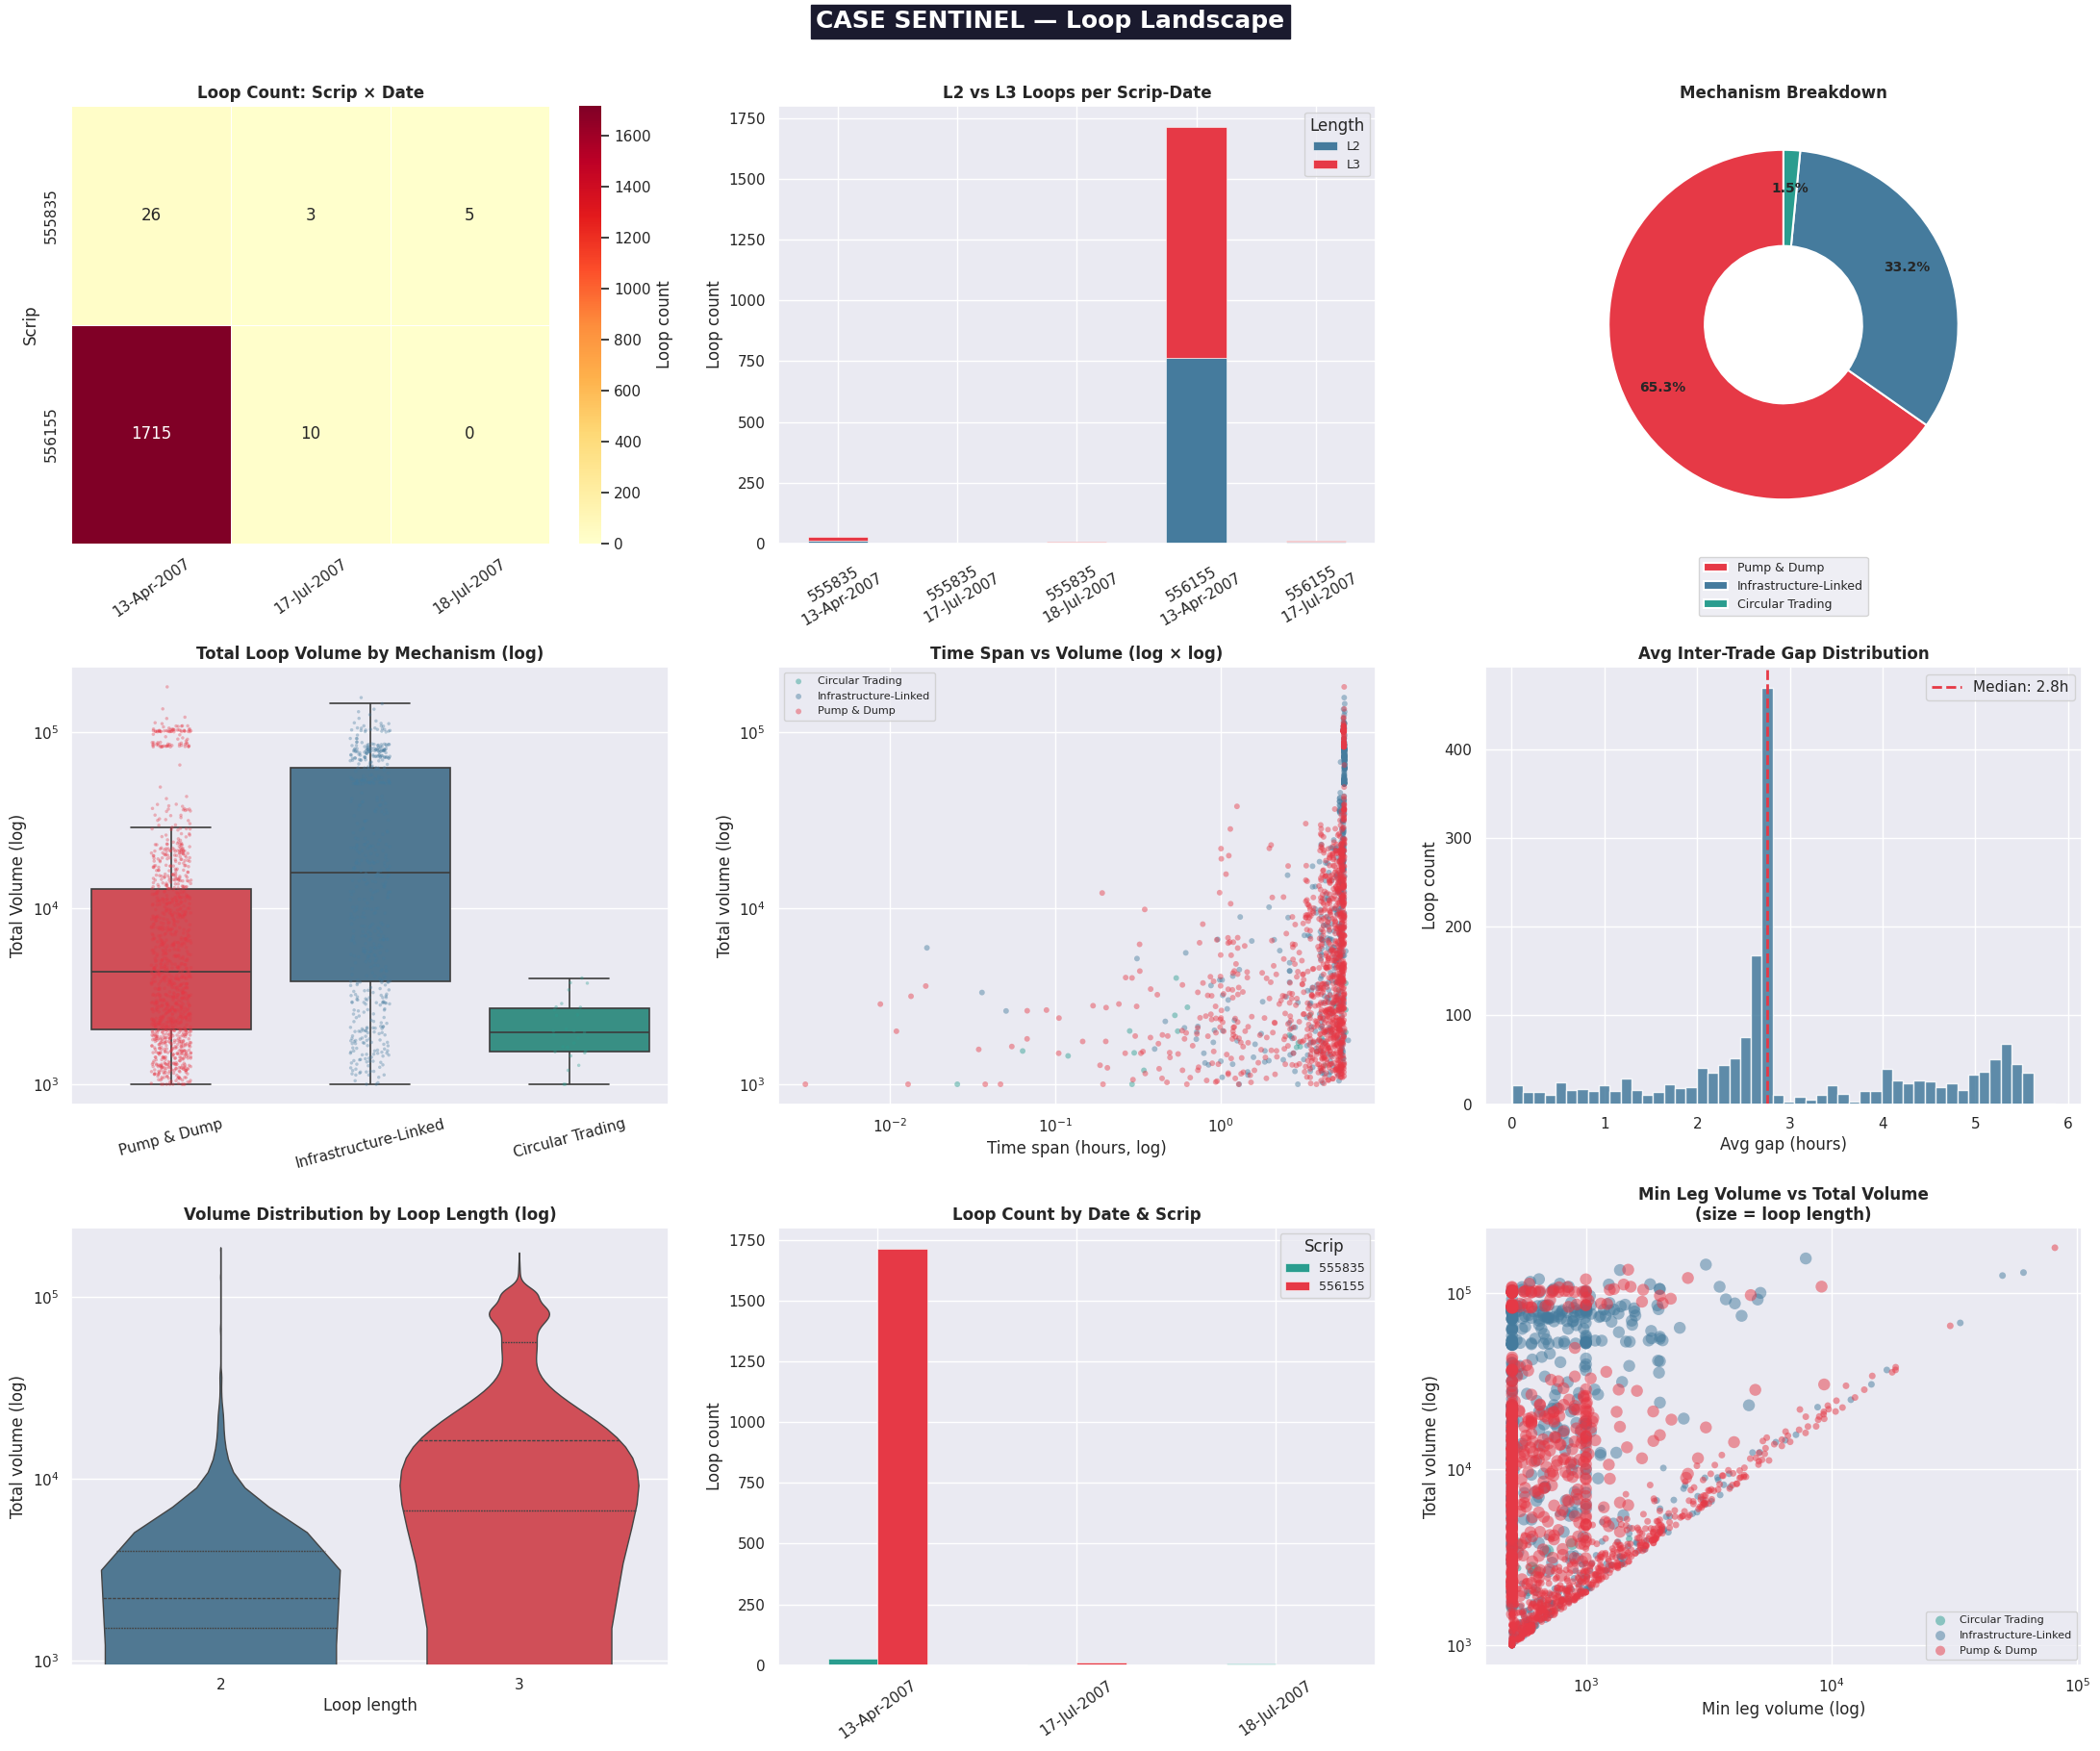

Figure 1 saved → sentinel_viz_fig1_loops.png


In [8]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

# ── Global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')
PALETTE   = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']
MECH_CLR  = {'Pump & Dump': '#E63946', 'Infrastructure-Linked': '#457B9D',
             'Circular Trading': '#2A9D8F'}
TIER_CLR  = {'LOW': '#2A9D8F', 'MEDIUM': '#E9C46A', 'HIGH': '#F4A261', 'CRITICAL': '#E63946'}


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Loop Landscape   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(3, 3, figsize=(22, 18))
fig1.suptitle('CASE SENTINEL — Loop Landscape', fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# ── 1a. HEATMAP  Loops per Scrip × Date ──────────────────────────────────────
ax = axes[0, 0]
heat = (optimized_loops_df.groupby(['SCRIP_CODE', 'TRADE_DATE'])
        .size().reset_index(name='count')
        .pivot(index='SCRIP_CODE', columns='TRADE_DATE', values='count').fillna(0))
sns.heatmap(heat, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=.5, cbar_kws={'label': 'Loop count'})
ax.set_title('Loop Count: Scrip × Date', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Scrip')
ax.tick_params(axis='x', rotation=35)

# ── 1b. STACKED BAR  L2 vs L3 loops per Scrip × Date ────────────────────────
ax = axes[0, 1]
grp = (optimized_loops_df.groupby(['SCRIP_CODE', 'TRADE_DATE', 'loop_length'])
       .size().reset_index(name='n'))
grp['label'] = grp['SCRIP_CODE'] + '\n' + grp['TRADE_DATE']
pivot = grp.pivot_table(index='label', columns='loop_length', values='n', fill_value=0)
pivot.columns = [f'L{c}' for c in pivot.columns]
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=['#457B9D', '#E63946'], edgecolor='white', linewidth=0.4)
ax.set_title('L2 vs L3 Loops per Scrip-Date', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Loop count')
ax.legend(title='Length', fontsize=9)

# ── 1c. DONUT  Mechanism breakdown ───────────────────────────────────────────
ax = axes[0, 2]
mech_s = loops_full['mechanism'].value_counts()
wedge_colors = [MECH_CLR.get(m, '#888') for m in mech_s.index]
wedges, texts, autotexts = ax.pie(
    mech_s.values, labels=None,
    colors=wedge_colors, autopct='%1.1f%%', startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.legend(mech_s.index, loc='lower center', fontsize=9, ncol=1,
          bbox_to_anchor=(0.5, -0.18))
ax.set_title('Mechanism Breakdown', fontweight='bold')

# ── 1d. BOX PLOT  Volume distribution by Mechanism ───────────────────────────
ax = axes[1, 0]
order = ['Pump & Dump', 'Infrastructure-Linked', 'Circular Trading']
sns.boxplot(data=loops_full, x='mechanism', y='total_volume', order=order,
            palette=MECH_CLR, ax=ax, showfliers=False, linewidth=1.2)
sns.stripplot(data=loops_full, x='mechanism', y='total_volume', order=order,
              palette=MECH_CLR, ax=ax, size=2.5, alpha=0.35, jitter=True)
ax.set_yscale('log')
ax.set_title('Total Loop Volume by Mechanism (log)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Total Volume (log)')
ax.tick_params(axis='x', rotation=15)

# ── 1e. SCATTER  Time span vs Volume  (color = mechanism) ────────────────────
ax = axes[1, 1]
for mech, grp_df in loops_full.groupby('mechanism'):
    ax.scatter(grp_df['time_span_sec'] / 3600,
               grp_df['total_volume'],
               label=mech, color=MECH_CLR.get(mech, '#888'),
               alpha=0.45, s=18, edgecolors='none')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Time Span vs Volume (log × log)', fontweight='bold')
ax.set_xlabel('Time span (hours, log)'); ax.set_ylabel('Total volume (log)')
ax.legend(fontsize=8)

# ── 1f. HISTOGRAM  avg_gap_sec distribution ──────────────────────────────────
ax = axes[1, 2]
gap_data = loops_full['avg_gap_sec'].dropna()
ax.hist(gap_data / 3600, bins=50, color='#457B9D', edgecolor='white', alpha=0.85)
ax.axvline(gap_data.median() / 3600, color='#E63946', linewidth=2,
           linestyle='--', label=f'Median: {gap_data.median()/3600:.1f}h')
ax.set_title('Avg Inter-Trade Gap Distribution', fontweight='bold')
ax.set_xlabel('Avg gap (hours)'); ax.set_ylabel('Loop count')
ax.legend()

# ── 1g. VIOLIN  Volume by Loop Length ────────────────────────────────────────
ax = axes[2, 0]
sns.violinplot(data=loops_full, x='loop_length', y='total_volume',
               palette=['#457B9D', '#E63946'], ax=ax,
               inner='quartile', linewidth=1.0)
ax.set_yscale('log')
ax.set_title('Volume Distribution by Loop Length (log)', fontweight='bold')
ax.set_xlabel('Loop length'); ax.set_ylabel('Total volume (log)')

# ── 1h. GROUPED BAR  Loops per Date, coloured by Scrip ───────────────────────
ax = axes[2, 1]
date_scrip = (optimized_loops_df.groupby(['TRADE_DATE', 'SCRIP_CODE'])
              .size().reset_index(name='n'))
pivot2 = date_scrip.pivot(index='TRADE_DATE', columns='SCRIP_CODE', values='n').fillna(0)
pivot2.plot(kind='bar', ax=ax, color=['#2A9D8F', '#E63946'],
            edgecolor='white', linewidth=0.4)
ax.set_title('Loop Count by Date & Scrip', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Loop count')
ax.legend(title='Scrip', fontsize=9)

# ── 1i. SCATTER  min_leg_volume vs total_volume  (size = loop_length) ─────────
ax = axes[2, 2]
szmap = {2: 25, 3: 80}
for mech, grp_df in loops_full.groupby('mechanism'):
    sz = grp_df['loop_length'].map(szmap).fillna(40)
    ax.scatter(grp_df['min_leg_volume'], grp_df['total_volume'],
               c=MECH_CLR.get(mech, '#888'), s=sz, alpha=0.5,
               edgecolors='none', label=mech)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Min Leg Volume vs Total Volume\n(size = loop length)', fontweight='bold')
ax.set_xlabel('Min leg volume (log)'); ax.set_ylabel('Total volume (log)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_viz_fig1_loops.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved → sentinel_viz_fig1_loops.png")

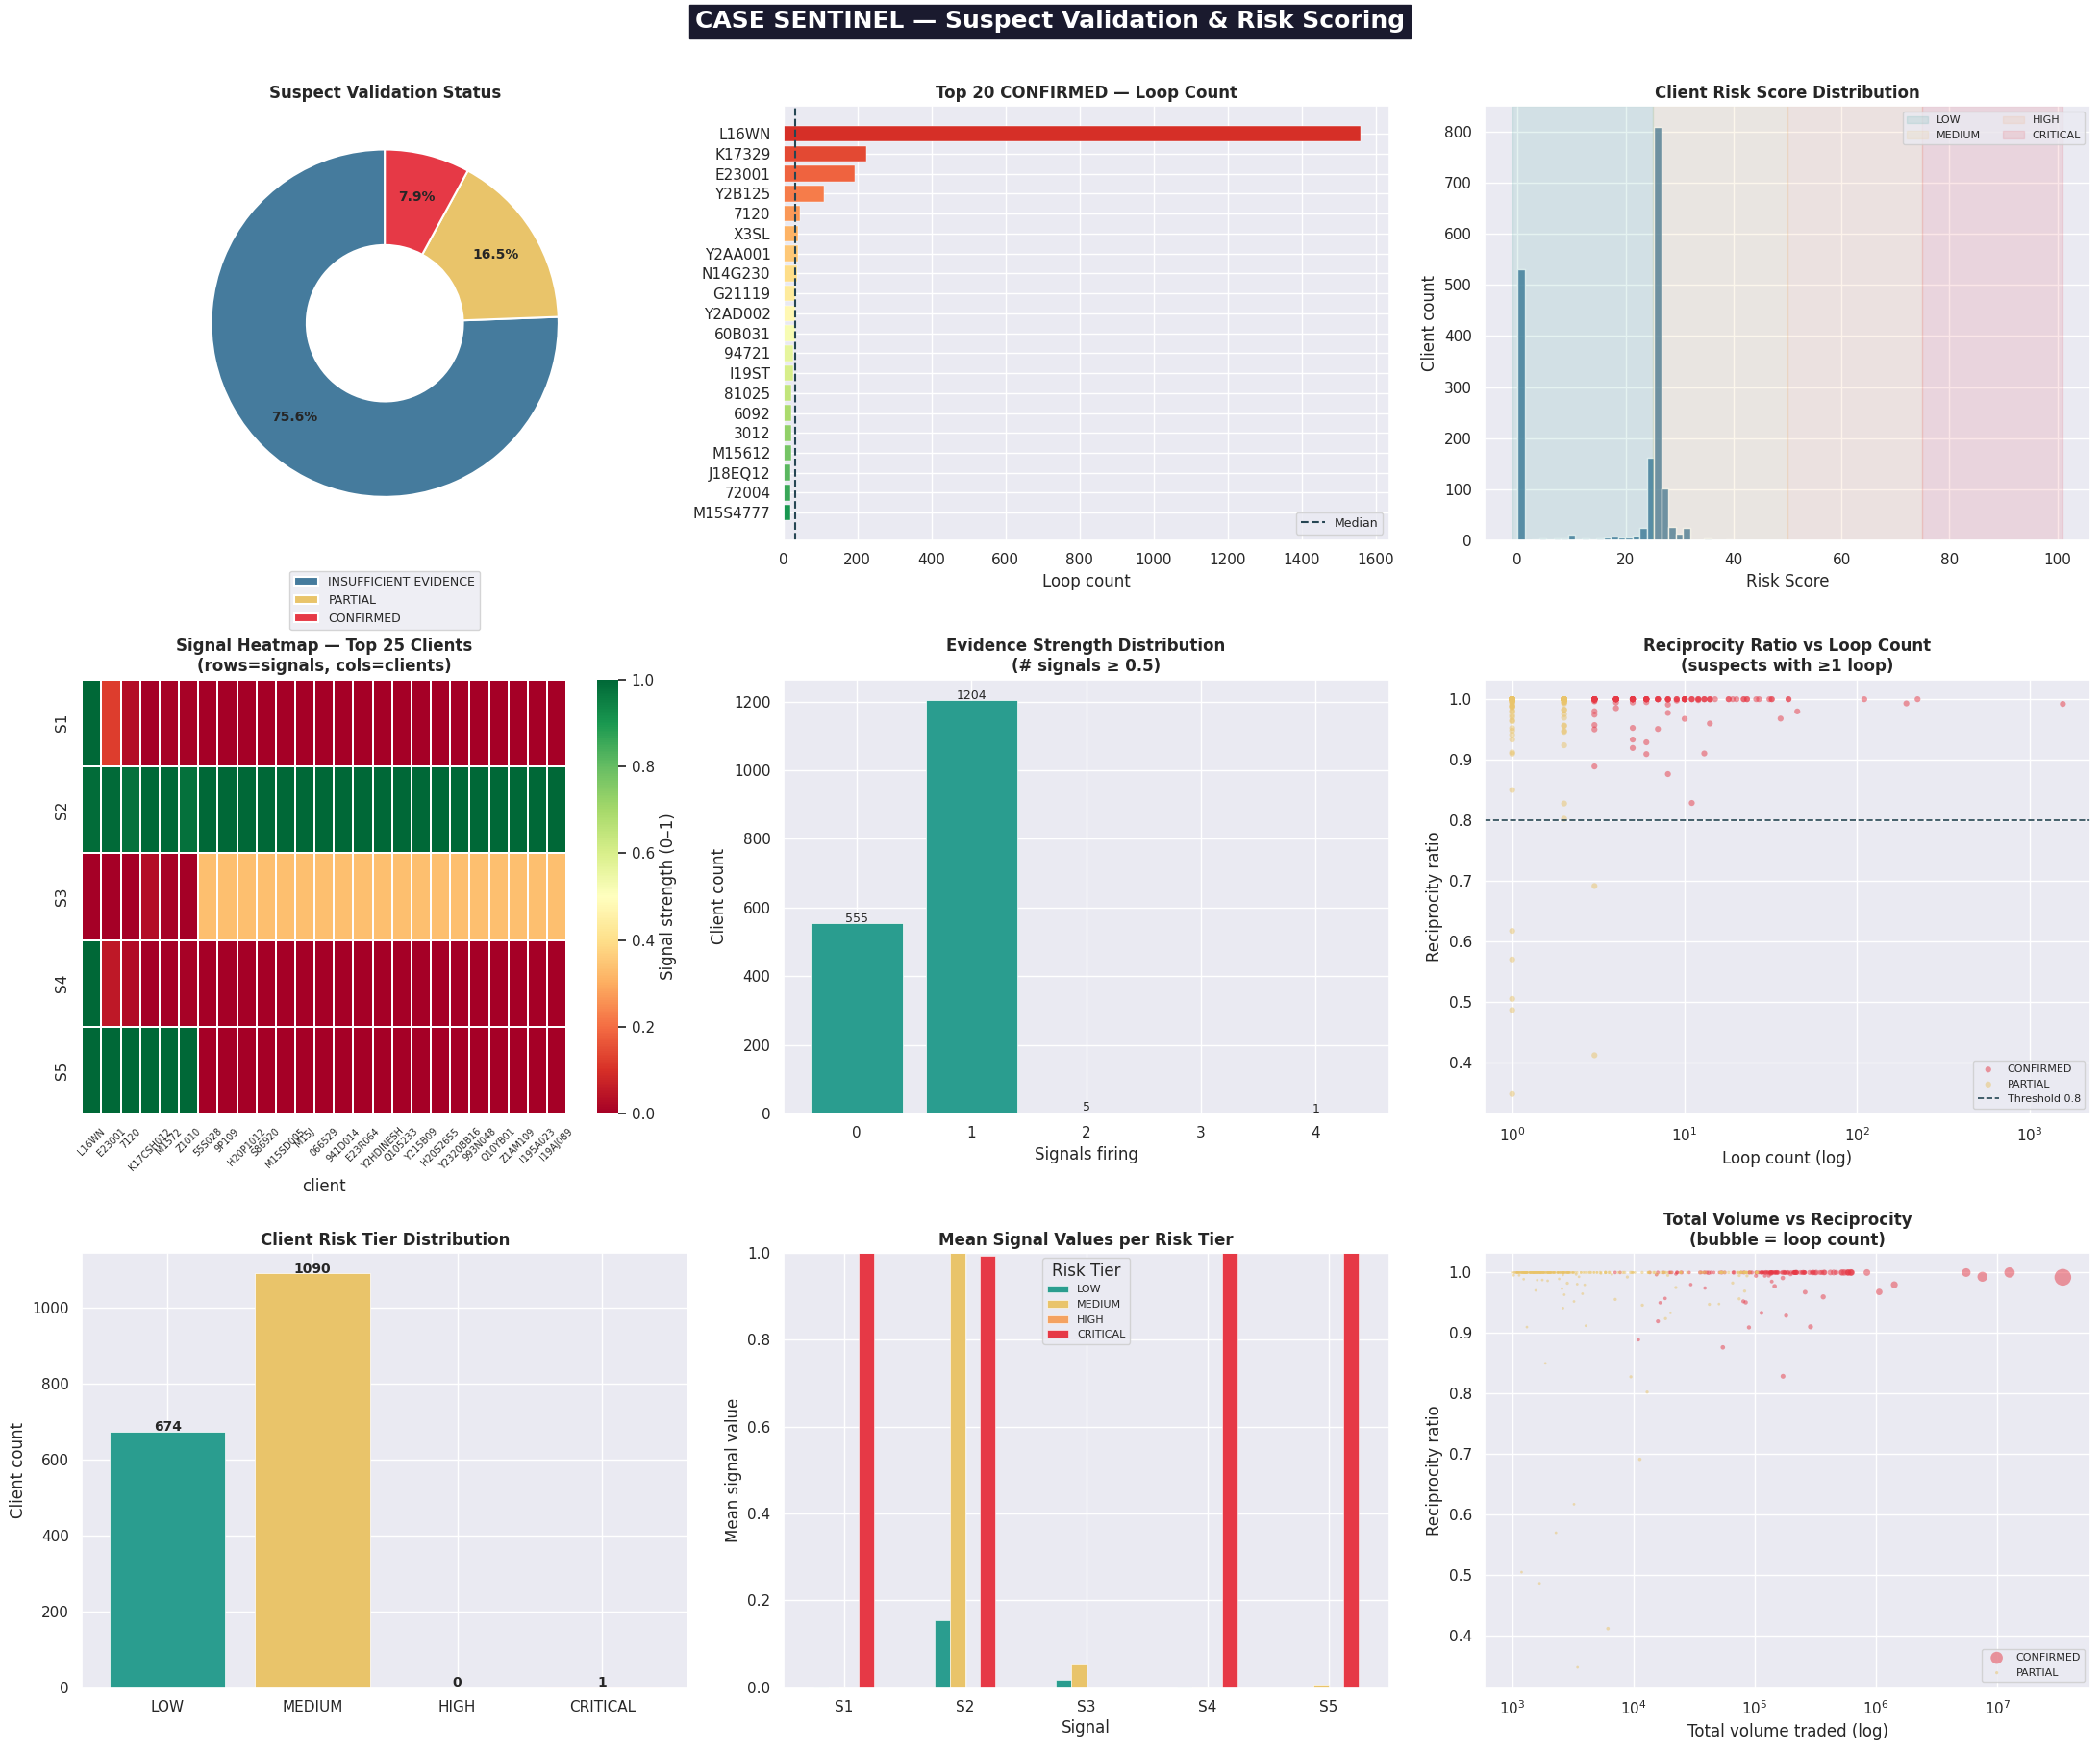

Figure 2 saved → sentinel_viz_fig2_suspects.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Suspect Validation & Risk Scoring   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(3, 3, figsize=(22, 18))
fig2.suptitle('CASE SENTINEL — Suspect Validation & Risk Scoring',
              fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# ── 2a. DONUT  Validation status ─────────────────────────────────────────────
ax = axes2[0, 0]
vstatus = validation['validation_status'].value_counts()
vcolors = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A',
           'INSUFFICIENT EVIDENCE': '#457B9D'}
wc = [vcolors.get(s, '#888') for s in vstatus.index]
wedges, texts, autotexts = ax.pie(
    vstatus.values, colors=wc, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.legend(vstatus.index, loc='lower center', fontsize=9,
          bbox_to_anchor=(0.5, -0.22))
ax.set_title('Suspect Validation Status', fontweight='bold')

# ── 2b. HORIZONTAL BAR  Top 20 confirmed clients by loop count ───────────────
ax = axes2[0, 1]
top_confirmed = (validation[validation['validation_status'] == 'CONFIRMED']
                 .sort_values('loop_count', ascending=False).head(20))
cmap_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_confirmed)))
bars = ax.barh(top_confirmed['client'][::-1],
               top_confirmed['loop_count'][::-1],
               color=cmap_bar, edgecolor='white', linewidth=0.3)
ax.set_title('Top 20 CONFIRMED — Loop Count', fontweight='bold')
ax.set_xlabel('Loop count')
ax.axvline(top_confirmed['loop_count'].median(), color='#264653',
           linestyle='--', linewidth=1.5, label='Median')
ax.legend(fontsize=9)

# ── 2c. HISTOGRAM  Risk score distribution with tier shading ─────────────────
ax = axes2[0, 2]
scores = client_scores_final['Risk_Score'].dropna()
ax.hist(scores, bins=60, color='#457B9D', edgecolor='white', alpha=0.85)
# Tier bands
tier_edges = [(-1, 25, '#2A9D8F', 'LOW'),
              (25, 50, '#E9C46A', 'MEDIUM'),
              (50, 75, '#F4A261', 'HIGH'),
              (75, 101, '#E63946', 'CRITICAL')]
for lo, hi, c, lbl in tier_edges:
    ax.axvspan(lo, hi, alpha=0.12, color=c, label=lbl)
ax.set_title('Client Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Client count')
ax.legend(fontsize=8, ncol=2)

# ── 2d. HEATMAP  Signal matrix for top 25 clients by Risk_Score ──────────────
ax = axes2[1, 0]
top25 = client_scores_final.head(25).set_index('client')[['S1','S2','S3','S4','S5']]
sns.heatmap(top25.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={'label': 'Signal strength (0–1)'},
            xticklabels=True, yticklabels=True)
ax.set_title('Signal Heatmap — Top 25 Clients\n(rows=signals, cols=clients)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# ── 2e. BAR  Evidence strength distribution ───────────────────────────────────
ax = axes2[1, 1]
es = client_scores_final['Evidence_Strength'].value_counts().sort_index()
bar_colors = [TIER_CLR.get(
    ['LOW','LOW','LOW','MEDIUM','HIGH','CRITICAL'][min(i, 5)], '#888')
    for i in es.index]
ax.bar(es.index, es.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_title('Evidence Strength Distribution\n(# signals ≥ 0.5)', fontweight='bold')
ax.set_xlabel('Signals firing'); ax.set_ylabel('Client count')
for i, v in zip(es.index, es.values):
    ax.text(i, v + 3, str(v), ha='center', fontsize=9)

# ── 2f. SCATTER  Reciprocity ratio vs Loop count (suspects) ──────────────────
ax = axes2[1, 2]
cmap_val = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A',
            'INSUFFICIENT EVIDENCE': '#457B9D'}
for status, grp_v in validation[validation['loop_count'] > 0].groupby('validation_status'):
    ax.scatter(grp_v['loop_count'], grp_v['reciprocity_ratio'],
               label=status, color=cmap_val.get(status, '#888'),
               alpha=0.5, s=20, edgecolors='none')
ax.set_xscale('log')
ax.set_title('Reciprocity Ratio vs Loop Count\n(suspects with ≥1 loop)',
             fontweight='bold')
ax.set_xlabel('Loop count (log)'); ax.set_ylabel('Reciprocity ratio')
ax.axhline(0.8, color='#264653', linestyle='--', linewidth=1.2, label='Threshold 0.8')
ax.legend(fontsize=8)

# ── 2g. BAR  Client Risk Tier breakdown ──────────────────────────────────────
ax = axes2[2, 0]
tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
tier_counts = client_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, tier_counts.values,
       color=[TIER_CLR[t] for t in tier_order],
       edgecolor='white', linewidth=0.5)
ax.set_title('Client Risk Tier Distribution', fontweight='bold')
ax.set_ylabel('Client count')
for i, (t, v) in enumerate(zip(tier_order, tier_counts)):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

# ── 2h. RADAR / BAR  Average signal values across Risk Tiers ─────────────────
ax = axes2[2, 1]
signal_means = (client_scores_final
                .groupby('Risk_Tier')[['S1','S2','S3','S4','S5']].mean()
                .reindex(['LOW','MEDIUM','HIGH','CRITICAL']))
signal_means.T.plot(kind='bar', ax=ax,
                    color=[TIER_CLR[t] for t in ['LOW','MEDIUM','HIGH','CRITICAL']],
                    edgecolor='white', linewidth=0.4)
ax.set_title('Mean Signal Values per Risk Tier', fontweight='bold')
ax.set_xlabel('Signal'); ax.set_ylabel('Mean signal value')
ax.set_ylim(0, 1); ax.legend(title='Risk Tier', fontsize=8)
ax.tick_params(axis='x', rotation=0)

# ── 2i. SCATTER  Total volume vs reciprocity (suspects, size = loop_count) ───
ax = axes2[2, 2]
plot_df = validation[(validation['loop_count'] > 0) & (validation['total_volume'] > 0)].copy()
plot_df['sz'] = np.sqrt(plot_df['loop_count']) * 4
for status, grp_v in plot_df.groupby('validation_status'):
    ax.scatter(grp_v['total_volume'], grp_v['reciprocity_ratio'],
               s=grp_v['sz'], alpha=0.5,
               color=cmap_val.get(status, '#888'),
               edgecolors='none', label=status)
ax.set_xscale('log')
ax.set_title('Total Volume vs Reciprocity\n(bubble = loop count)',
             fontweight='bold')
ax.set_xlabel('Total volume traded (log)'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_viz_fig2_suspects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved → sentinel_viz_fig2_suspects.png")

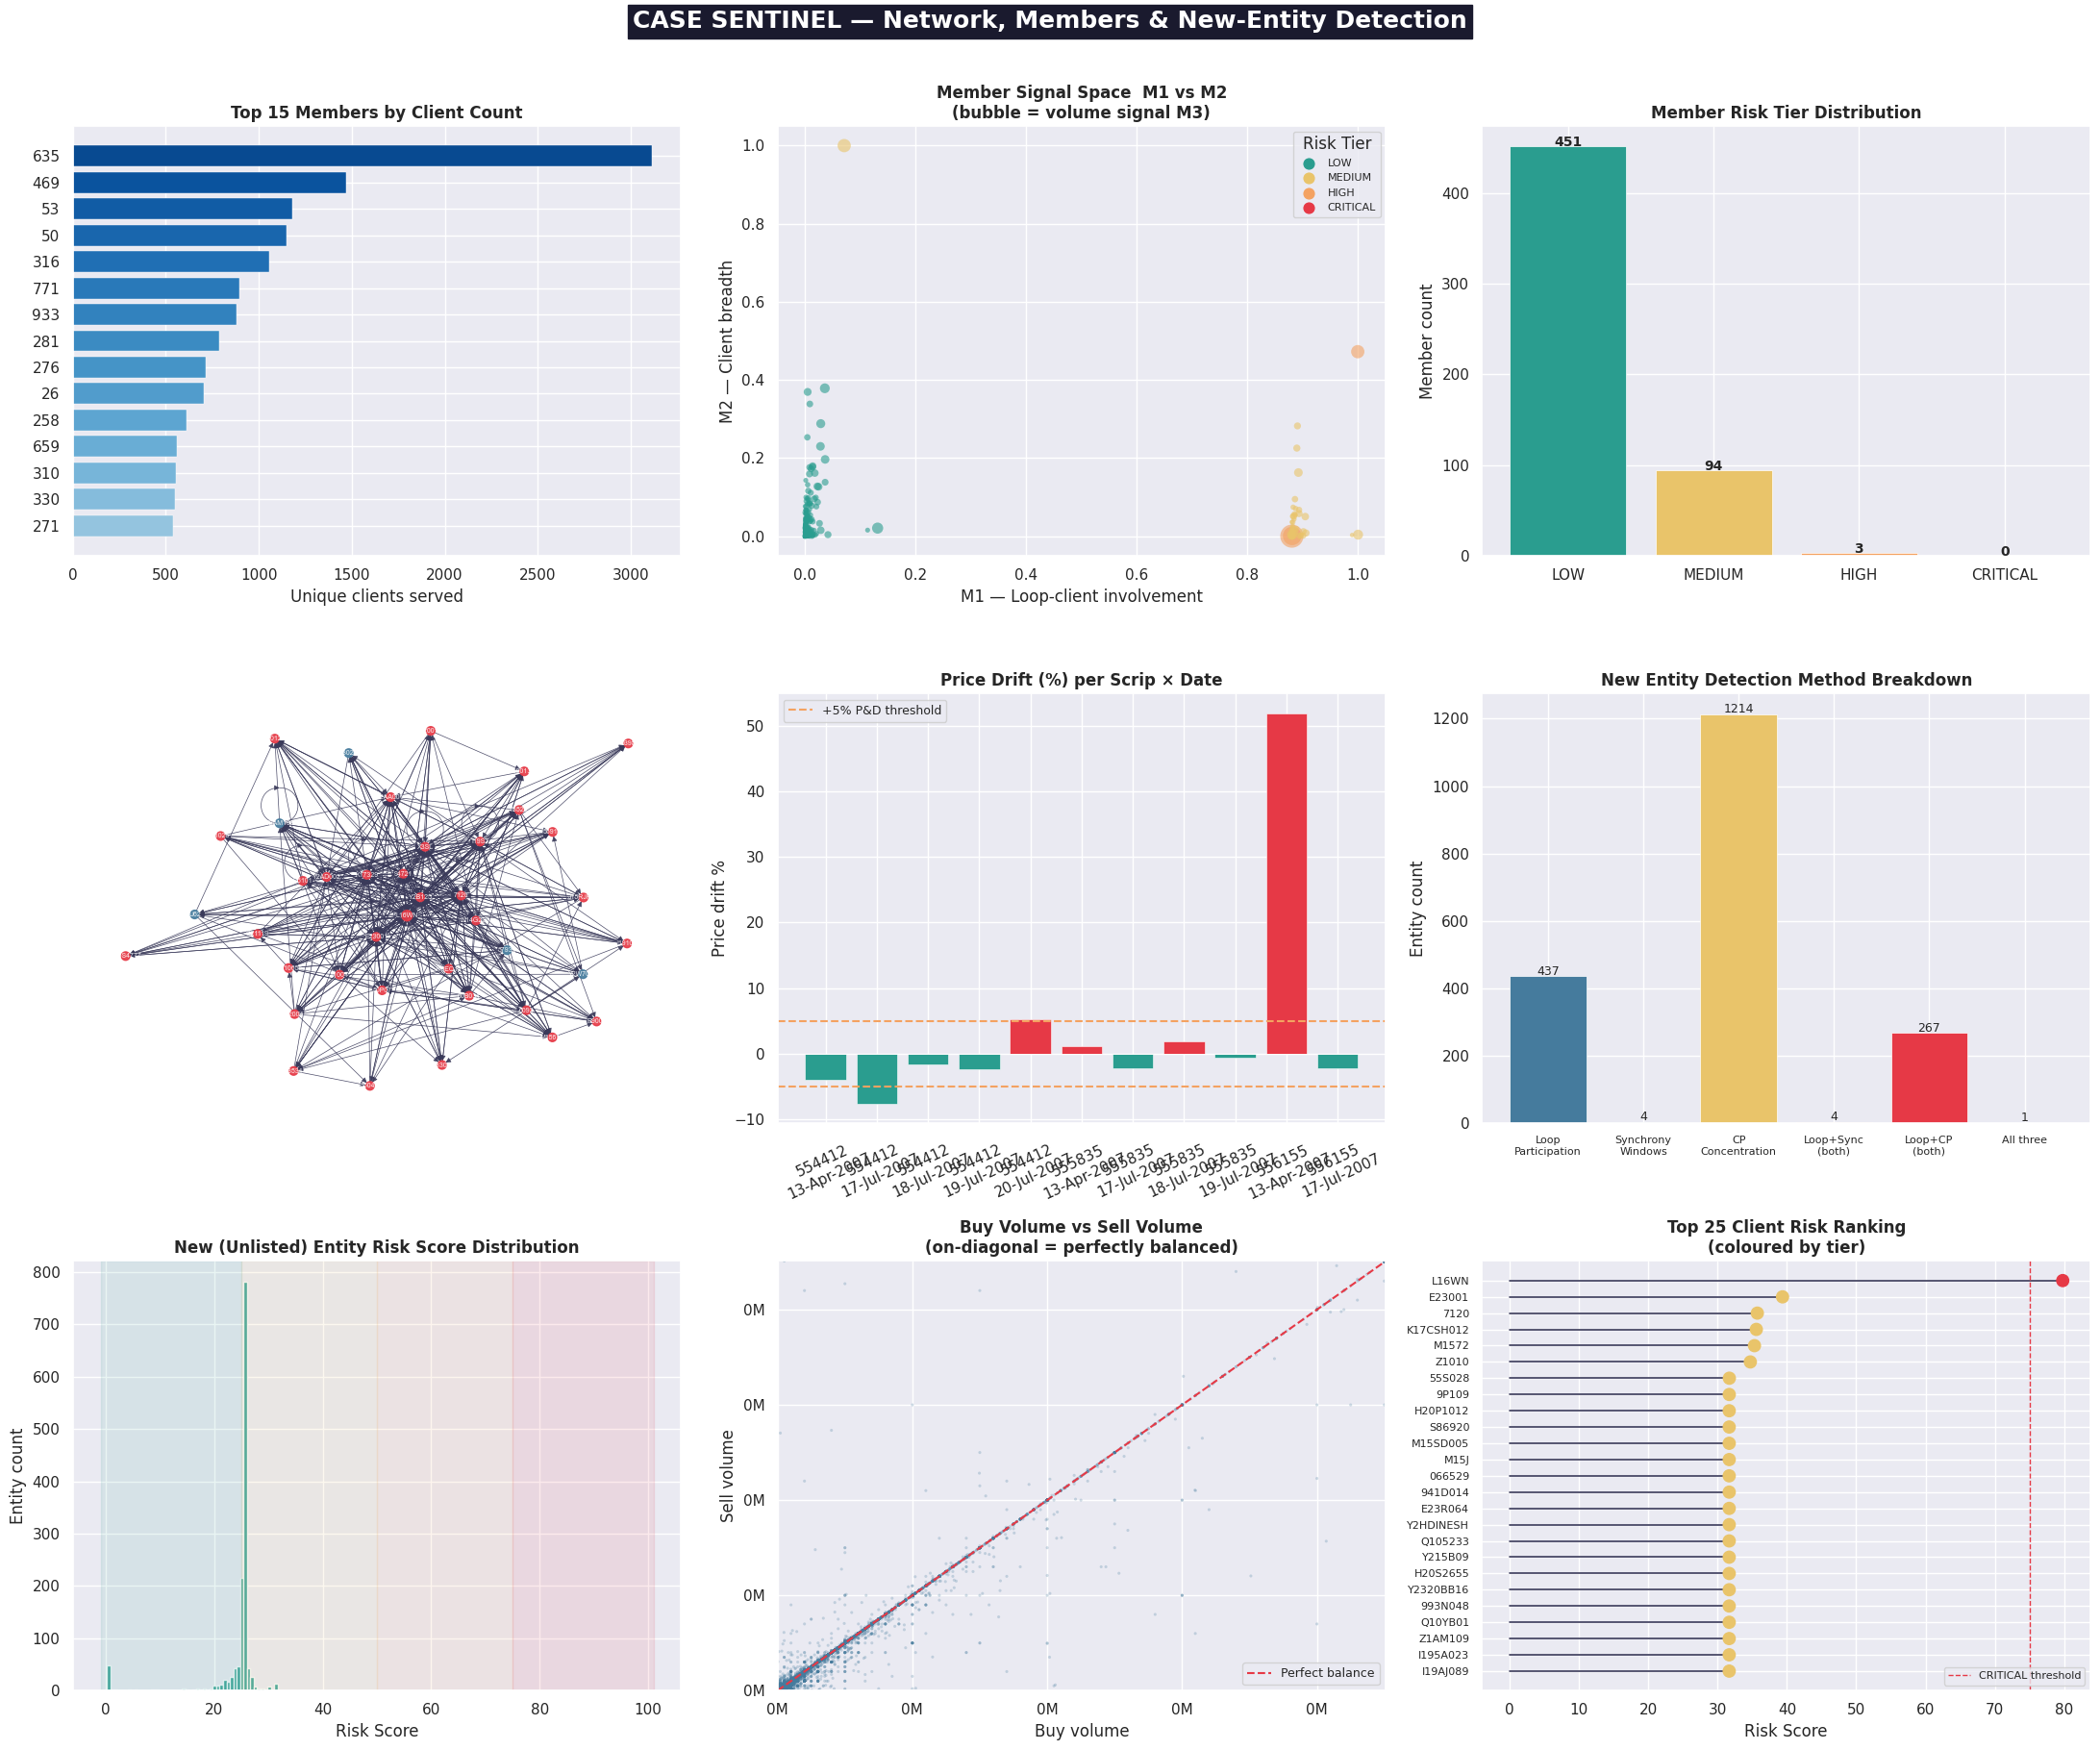

Figure 3 saved → sentinel_viz_fig3_network.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Network, Members & New Entities   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(3, 3, figsize=(22, 18))
fig3.suptitle('CASE SENTINEL — Network, Members & New-Entity Detection',
              fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# ── 3a. HORIZONTAL BAR  Top 15 members by client count ───────────────────────
ax = axes3[0, 0]
top_mb = member_stats.head(15)
bar_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_mb)))
ax.barh(top_mb['member_code'].astype(str)[::-1],
        top_mb['client_count'][::-1],
        color=bar_c, edgecolor='white', linewidth=0.3)
ax.set_title('Top 15 Members by Client Count', fontweight='bold')
ax.set_xlabel('Unique clients served')

# ── 3b. SCATTER  Member risk  M1 vs M2  (bubble = M3 = volume) ───────────────
ax = axes3[0, 1]
ms = member_scores_final.copy()
tier_c = [TIER_CLR.get(str(t), '#888') for t in ms['Risk_Tier']]
sc = ax.scatter(ms['M1'], ms['M2'],
                s=(ms['M3'] * 300 + 10).clip(10, 300),
                c=tier_c, alpha=0.6, edgecolors='none')
ax.set_title('Member Signal Space  M1 vs M2\n(bubble = volume signal M3)',
             fontweight='bold')
ax.set_xlabel('M1 — Loop-client involvement')
ax.set_ylabel('M2 — Client breadth')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.legend(title='Risk Tier', fontsize=8)

# ── 3c. MEMBER RISK TIER  bar ─────────────────────────────────────────────────
ax = axes3[0, 2]
tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
m_tier_counts = member_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, m_tier_counts.values,
       color=[TIER_CLR[t] for t in tier_order],
       edgecolor='white', linewidth=0.5)
ax.set_title('Member Risk Tier Distribution', fontweight='bold')
ax.set_ylabel('Member count')
for i, (t, v) in enumerate(zip(tier_order, m_tier_counts)):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

# ── 3d. NETWORKX  Subgraph of top loop participants ───────────────────────────
ax = axes3[1, 0]
ax.set_facecolor('#0D1117')

# Take top-40 clients by loop_count as subgraph nodes
top_nodes = loop_stats.sort_values('loop_count', ascending=False).head(40)['client'].tolist()
top_set   = set(top_nodes)

sub_edges = [
    (str(u), str(v))
    for u, v, d in Client_DG.edges(data=True)
    if str(u) in top_set and str(v) in top_set
]
H = nx.DiGraph()
H.add_nodes_from(top_nodes)
H.add_edges_from(sub_edges)

# Node size ∝ loop_count; colour by validation_status
loop_count_map = loop_stats.set_index('client')['loop_count'].to_dict()
vstatus_map    = validation.set_index('client')['validation_status'].to_dict()
node_sizes  = [max(loop_count_map.get(n, 1) * 0.04, 40) for n in H.nodes()]
node_colors = [{'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A'}
               .get(vstatus_map.get(n, 'X'), '#457B9D') for n in H.nodes()]

pos = nx.spring_layout(H, k=1.2, seed=42)
nx.draw_networkx(H, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                 edge_color='#3A3A5A', arrows=True, arrowsize=8,
                 with_labels=True, font_size=5, font_color='white',
                 width=0.5, alpha=0.9)
ax.set_title('Client Trade Network — Top 40 Loop Participants\n'
             '(red=CONFIRMED, yellow=PARTIAL, blue=other)',
             fontweight='bold', color='white')
ax.set_axis_off()

# ── 3e. TIMELINE  Price drift per scrip per date ─────────────────────────────
ax = axes3[1, 1]
pp = price_pivot.copy()
pp['label'] = pp['SCRIP_CODE'] + '\n' + pp['TRADE_DATE']
bar_drift_c = ['#E63946' if v >= 0 else '#2A9D8F' for v in pp['price_drift_pct']]
ax.bar(pp['label'], pp['price_drift_pct'],
       color=bar_drift_c, edgecolor='white', linewidth=0.4)
ax.axhline(5, color='#F4A261', linestyle='--', linewidth=1.5, label='+5% P&D threshold')
ax.axhline(-5, color='#F4A261', linestyle='--', linewidth=1.5)
ax.axhline(0, color='white', linewidth=0.6)
ax.set_title('Price Drift (%) per Scrip × Date', fontweight='bold')
ax.set_ylabel('Price drift %'); ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9)

# ── 3f. BAR  New entity detection method breakdown ───────────────────────────
ax = axes3[1, 2]
method_counts = {
    'Loop\nParticipation': len(new_from_loops),
    'Synchrony\nWindows': len(sync_new),
    'CP\nConcentration': len(high_cp),
    'Loop+Sync\n(both)': len(new_from_loops.intersection(sync_new)),
    'Loop+CP\n(both)': len(new_from_loops.intersection(high_cp)),
    'All three': len(new_from_loops.intersection(sync_new).intersection(high_cp)),
}
colors_m = ['#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#E63946', '#264653']
ax.bar(method_counts.keys(), method_counts.values(),
       color=colors_m, edgecolor='white', linewidth=0.5)
ax.set_title('New Entity Detection Method Breakdown', fontweight='bold')
ax.set_ylabel('Entity count')
for i, (k, v) in enumerate(method_counts.items()):
    ax.text(i, v + 4, str(v), ha='center', fontsize=9)
ax.tick_params(axis='x', labelsize=8)

# ── 3g. HISTOGRAM  New entity risk scores ────────────────────────────────────
ax = axes3[2, 0]
new_scores = new_entities_final['Risk_Score'].dropna()
ax.hist(new_scores, bins=50, color='#2A9D8F', edgecolor='white', alpha=0.85)
for lo, hi, c, lbl in [(-1, 25, '#2A9D8F', 'LOW'), (25, 50, '#E9C46A', 'MEDIUM'),
                        (50, 75, '#F4A261', 'HIGH'), (75, 101, '#E63946', 'CRITICAL')]:
    ax.axvspan(lo, hi, alpha=0.1, color=c)
ax.set_title('New (Unlisted) Entity Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Entity count')

# ── 3h. SCATTER  Buy vol vs Sell vol (reciprocity cloud) ─────────────────────
ax = axes3[2, 1]
rd = recip_df[['buy_vol', 'sell_vol']].copy()
rd = rd[(rd['buy_vol'] > 0) & (rd['sell_vol'] > 0)]
ax.scatter(rd['buy_vol'], rd['sell_vol'],
           alpha=0.25, s=5, color='#457B9D', edgecolors='none')
lim_max = max(rd['buy_vol'].quantile(0.99), rd['sell_vol'].quantile(0.99))
ax.plot([0, lim_max], [0, lim_max], color='#E63946', linewidth=1.5,
        linestyle='--', label='Perfect balance')
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_title('Buy Volume vs Sell Volume\n(on-diagonal = perfectly balanced)',
             fontweight='bold')
ax.set_xlabel('Buy volume'); ax.set_ylabel('Sell volume')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(fontsize=9)

# ── 3i. RANKED DOT PLOT  Top 25 suspects risk score ranking ──────────────────
ax = axes3[2, 2]
top25_risk = client_scores_final.head(25).reset_index(drop=True)
dot_c = [TIER_CLR.get(str(t), '#888') for t in top25_risk['Risk_Tier']]
ax.scatter(top25_risk['Risk_Score'],
           range(len(top25_risk))[::-1],
           c=dot_c, s=80, zorder=3)
for i, row in top25_risk.iterrows():
    ax.plot([0, row['Risk_Score']], [len(top25_risk)-1-i, len(top25_risk)-1-i],
            color='#3A3A5A', linewidth=1.2, zorder=2)
ax.set_yticks(range(len(top25_risk)))
ax.set_yticklabels(top25_risk['client'][::-1], fontsize=8)
ax.set_xlabel('Risk Score')
ax.set_title('Top 25 Client Risk Ranking\n(coloured by tier)', fontweight='bold')
ax.axvline(75, color='#E63946', linestyle='--', linewidth=1, label='CRITICAL threshold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_viz_fig3_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved → sentinel_viz_fig3_network.png")

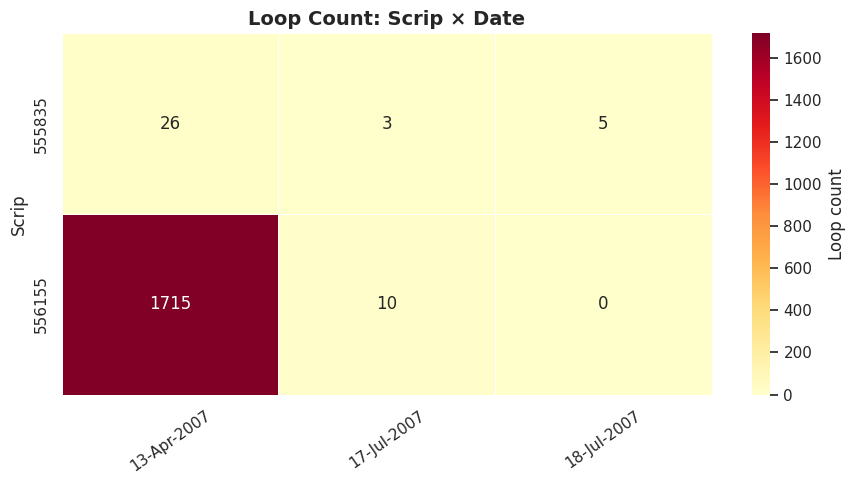

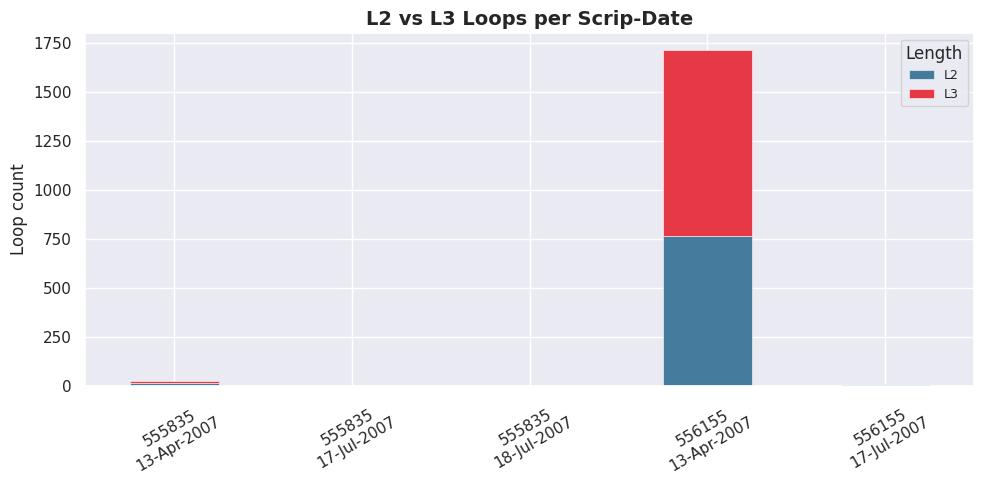

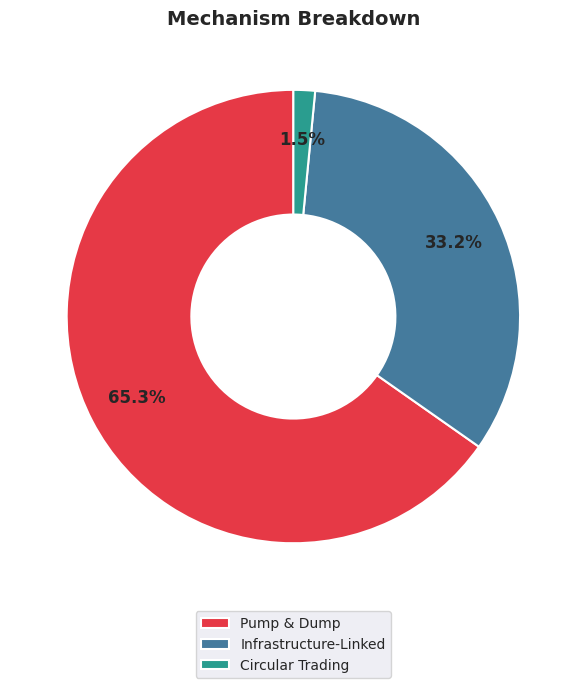

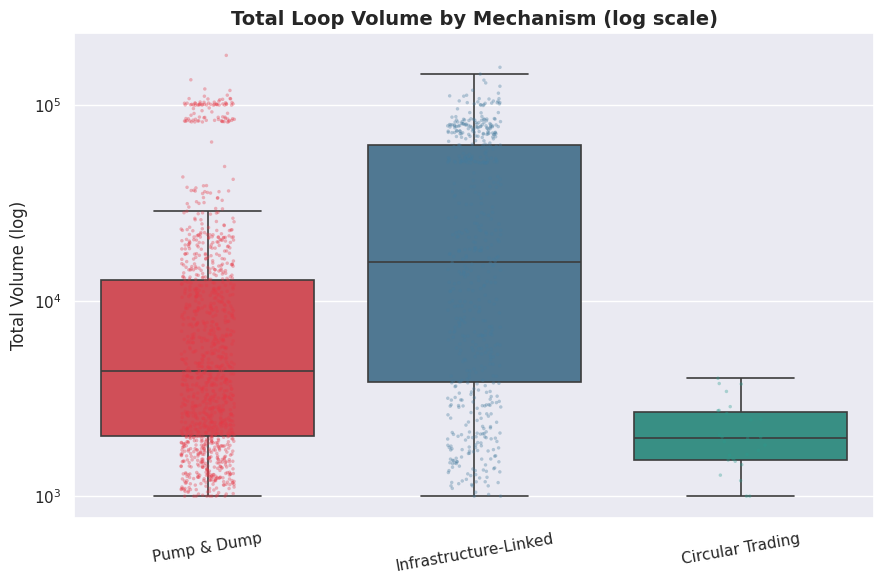

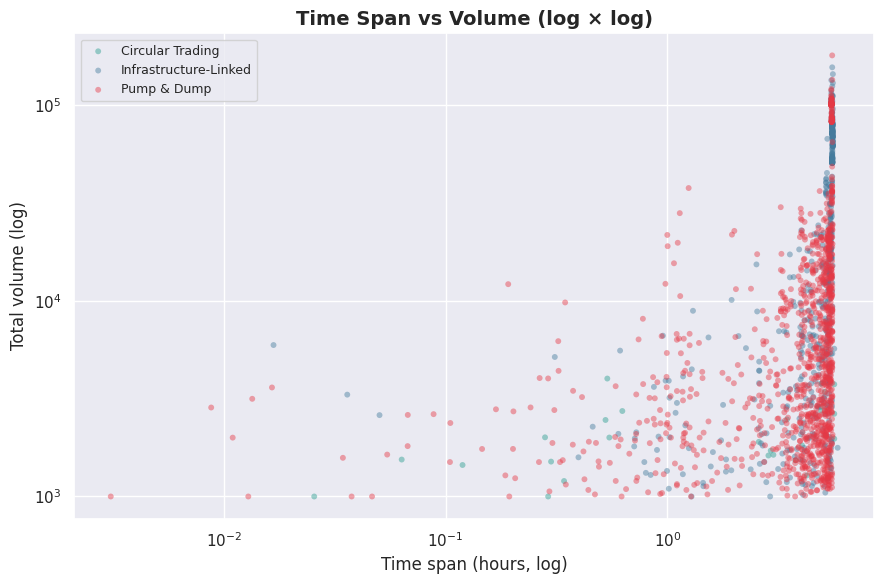

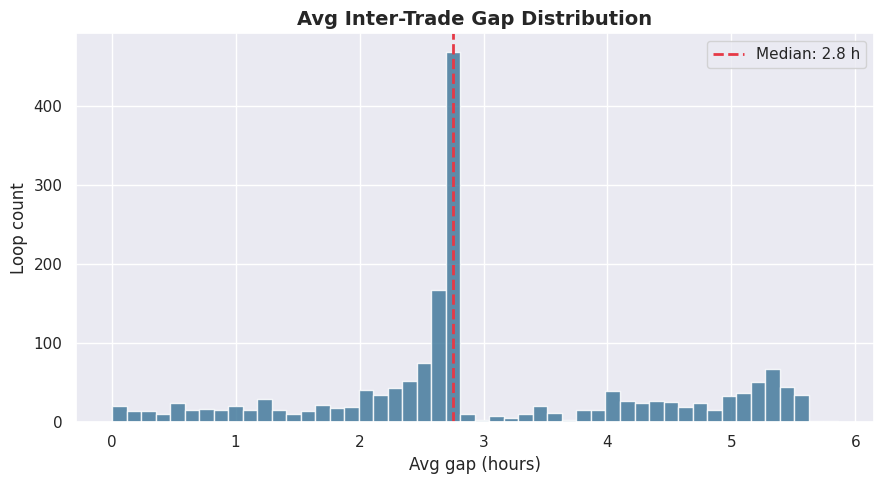

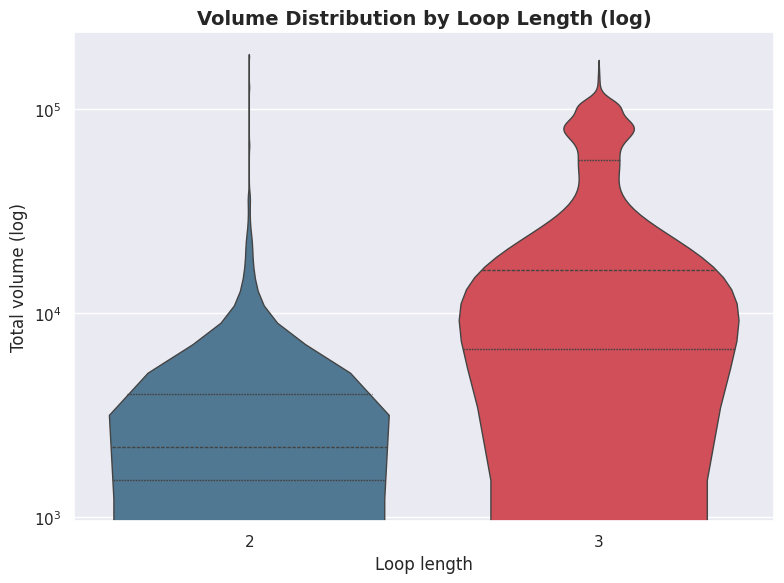

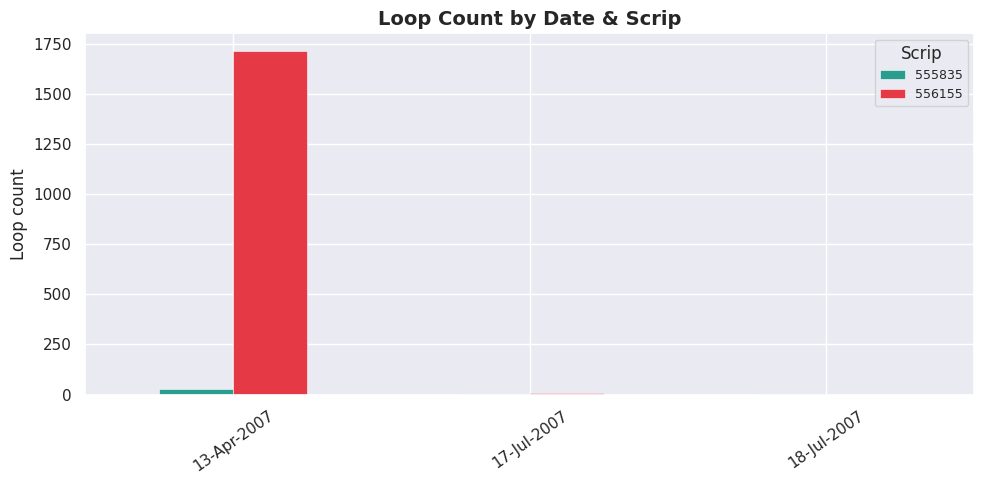

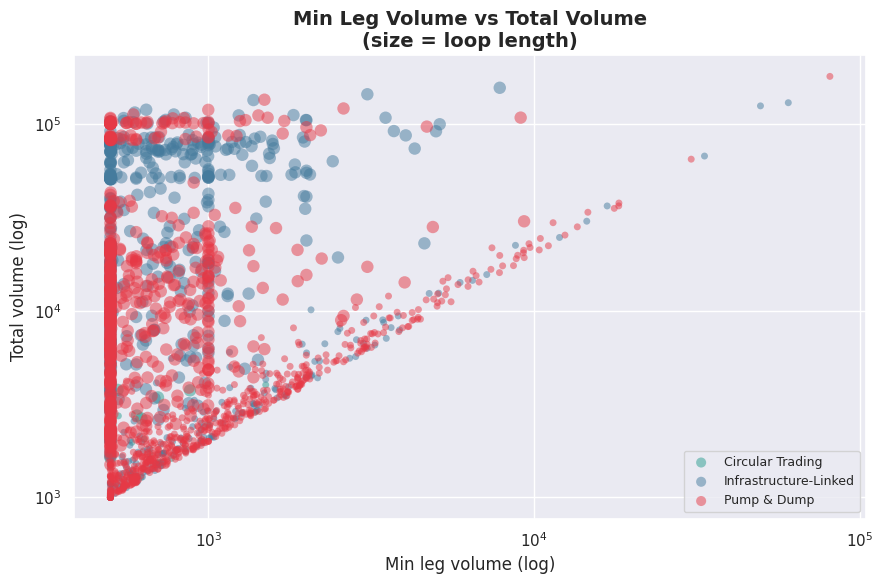

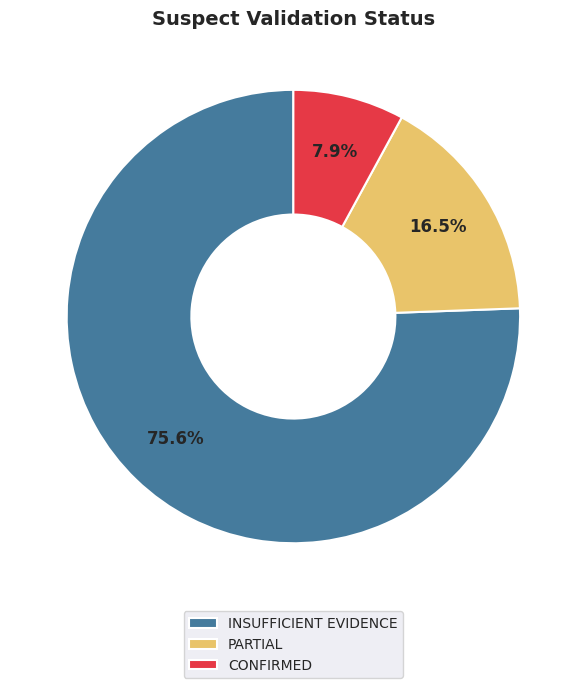

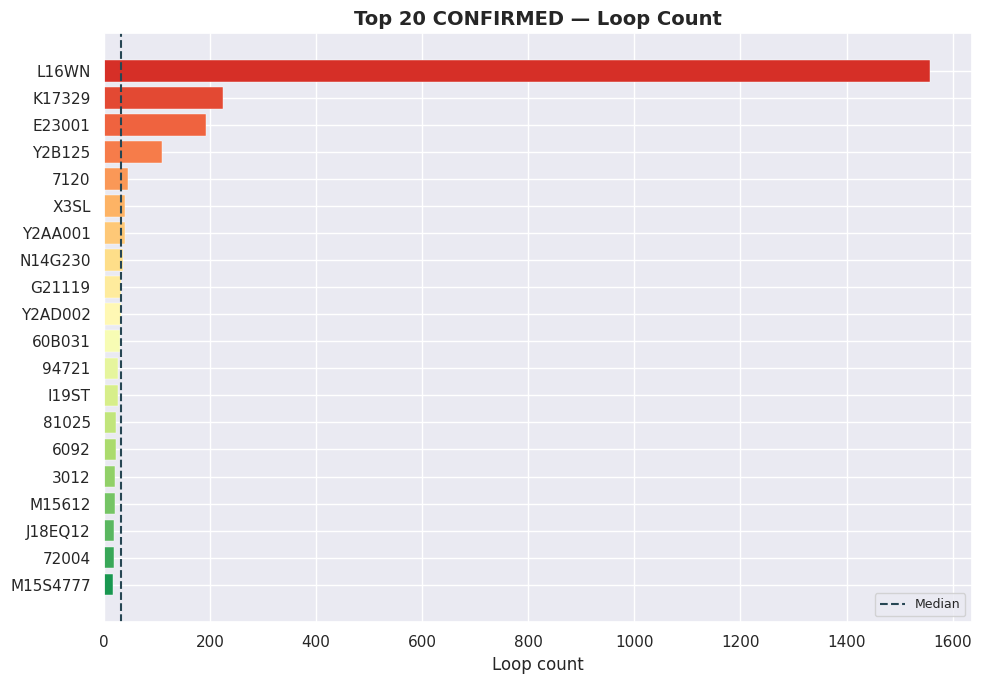

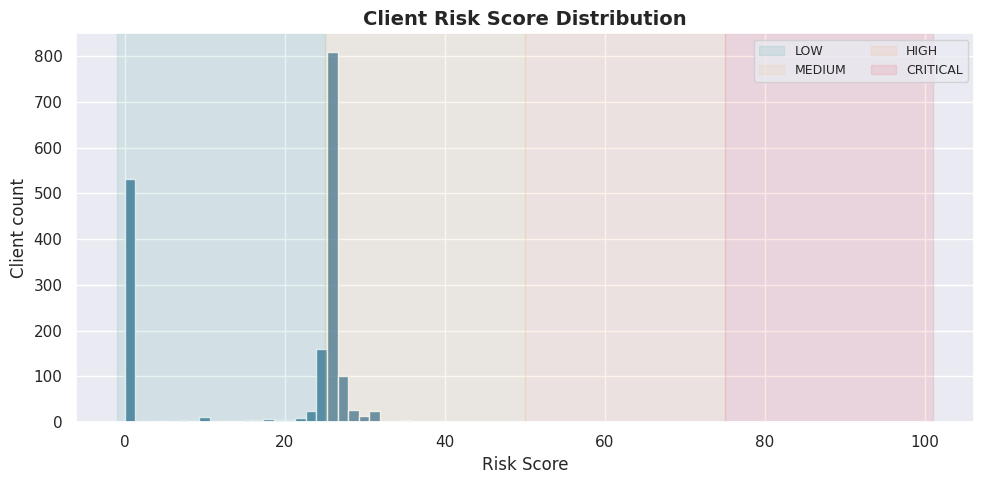

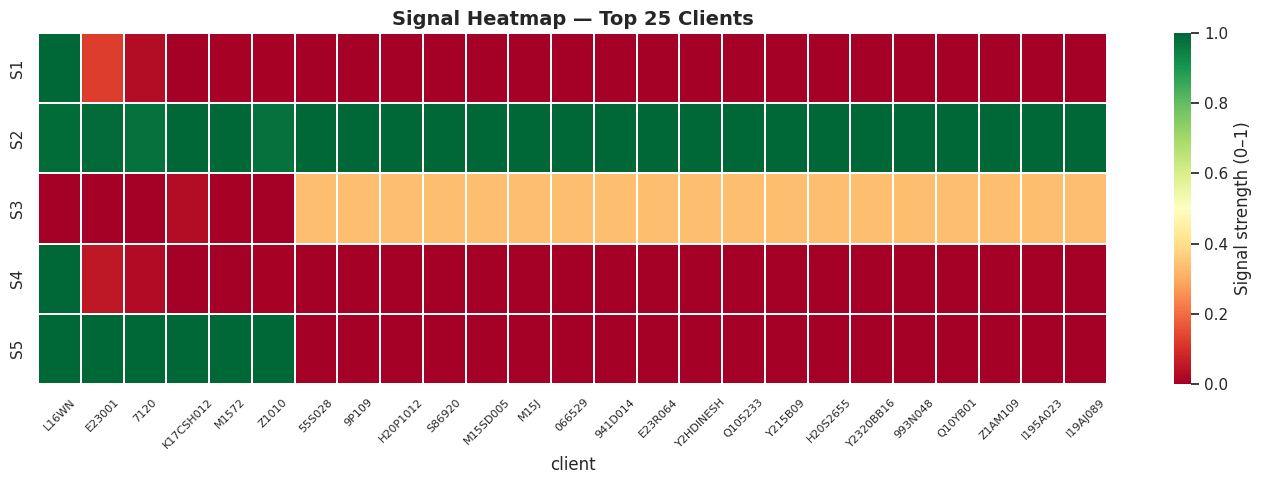

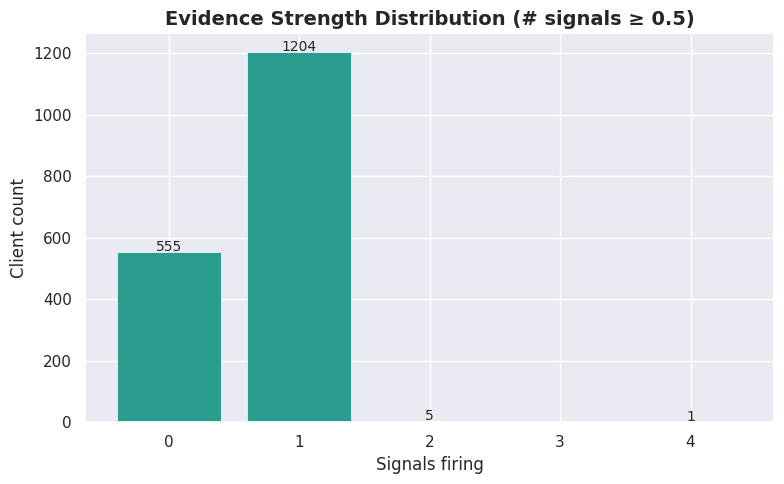

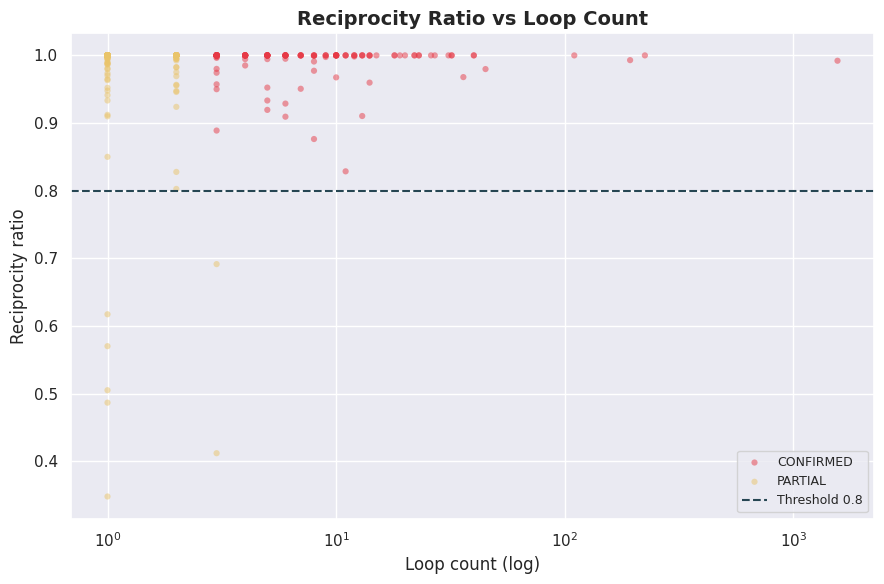

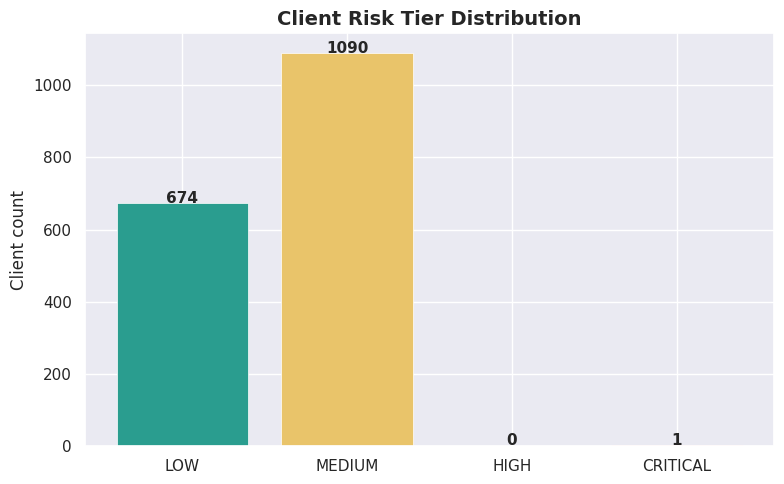

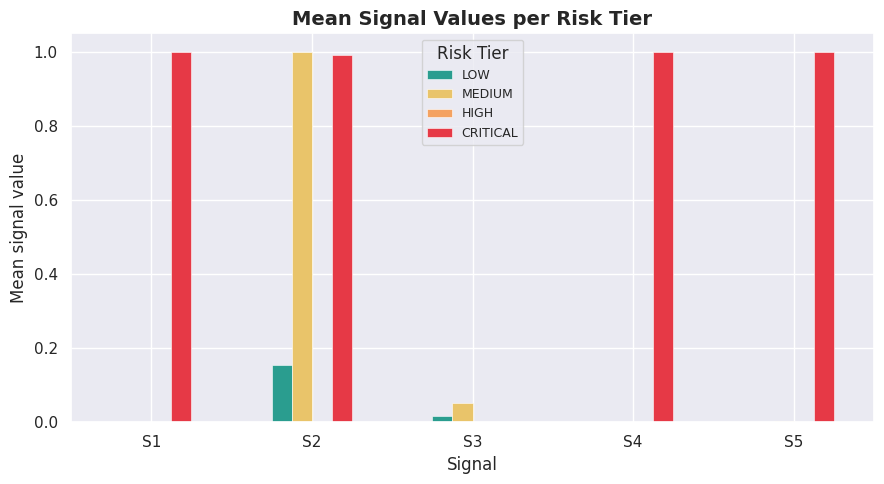

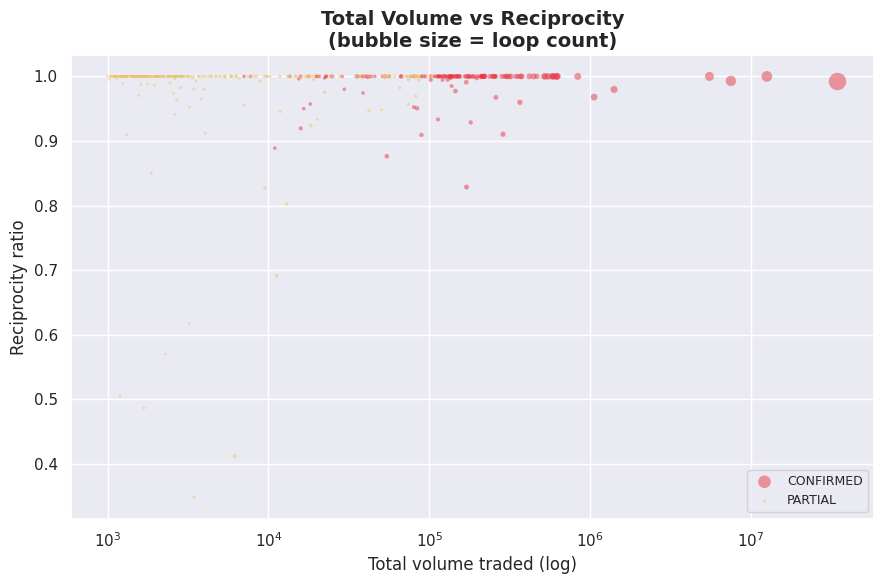

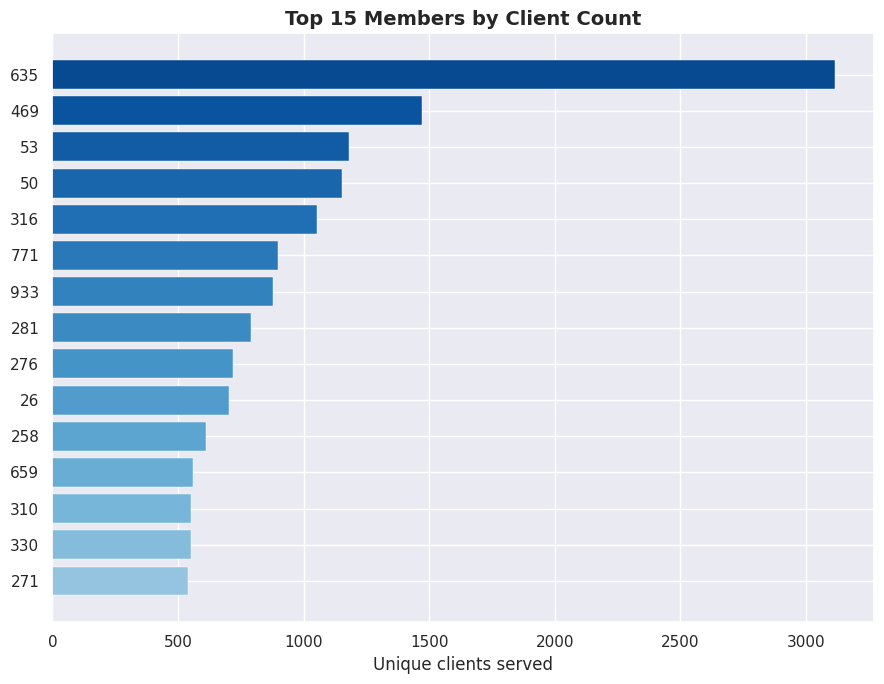

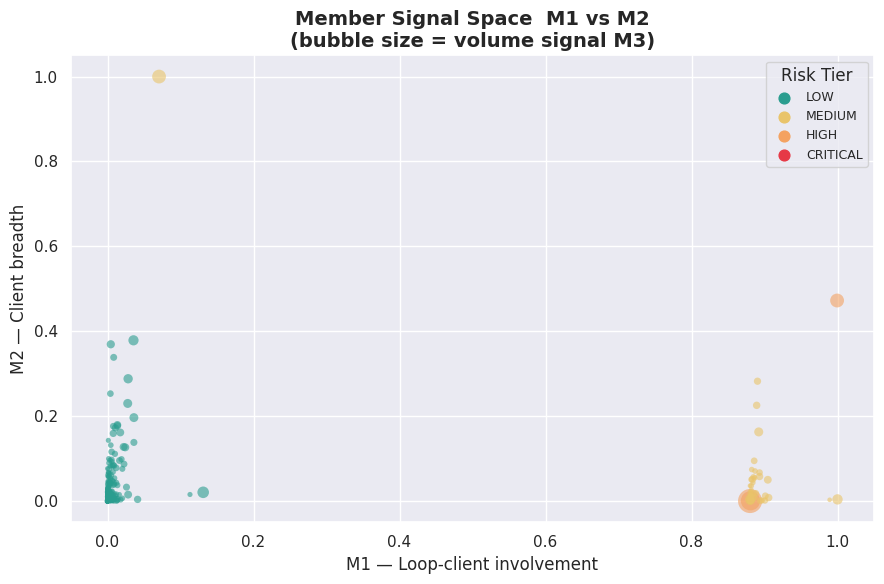

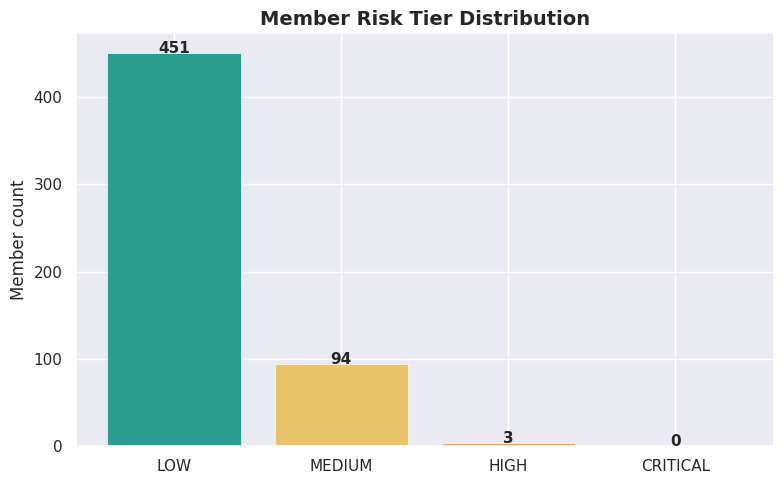

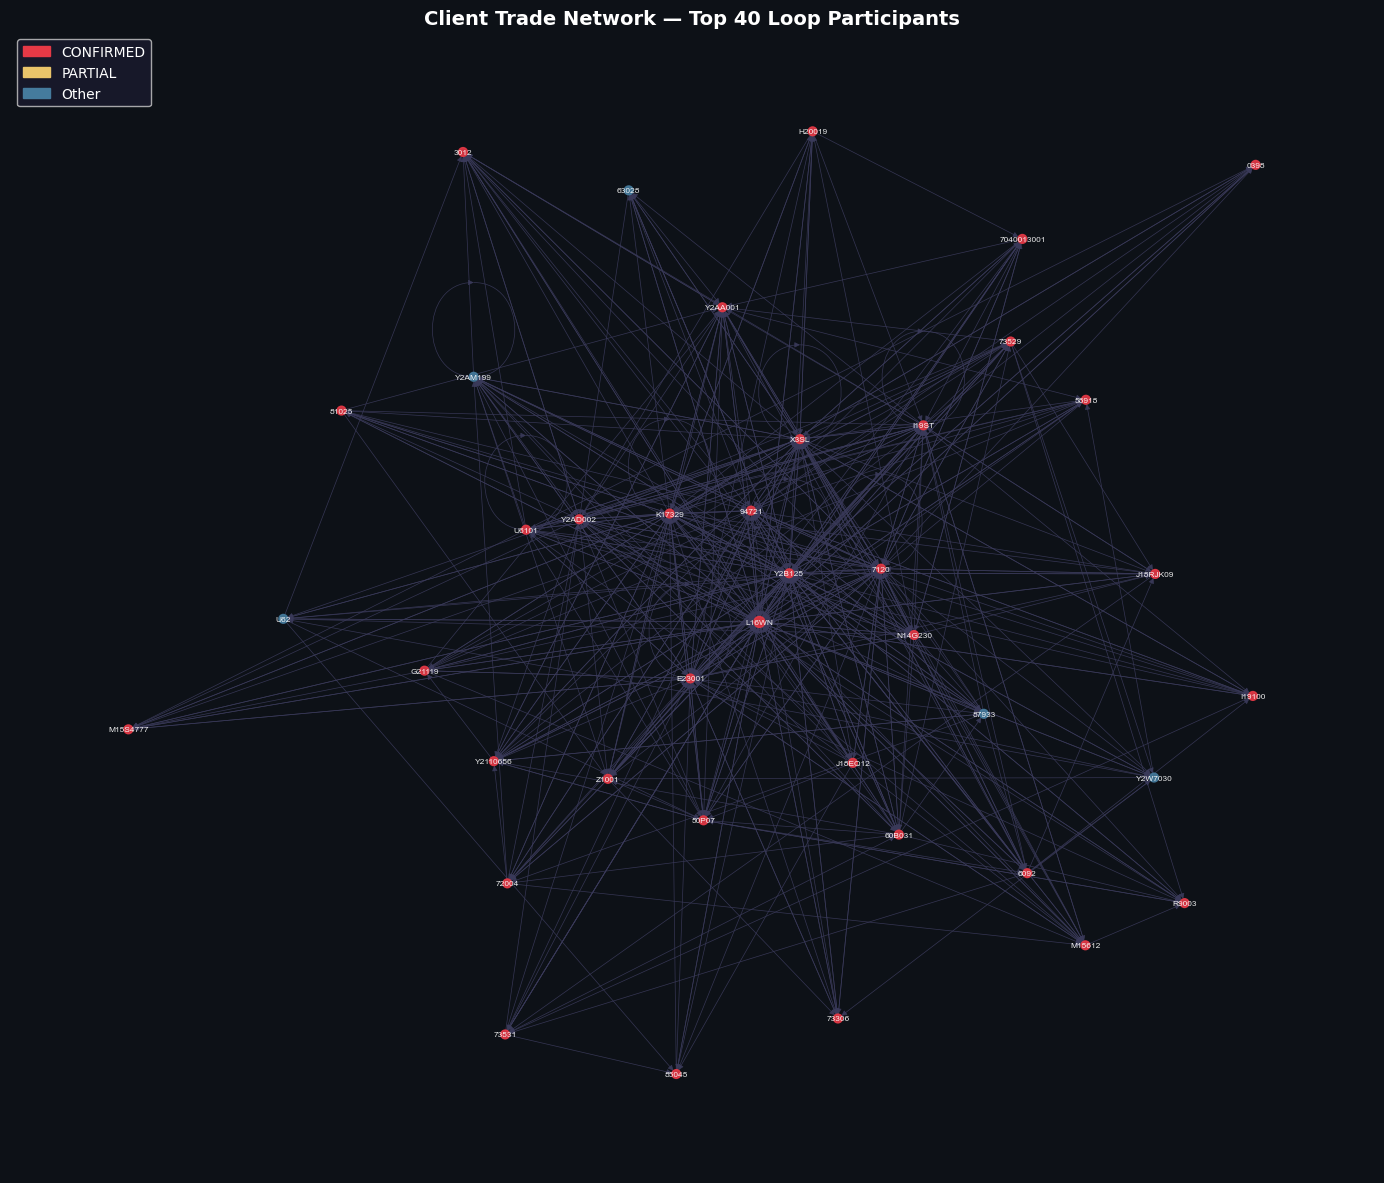

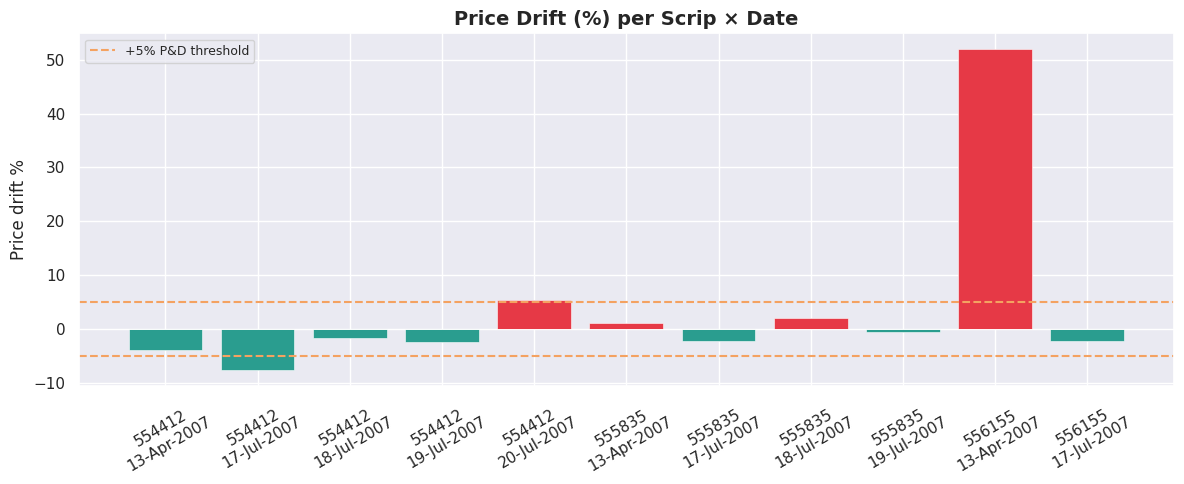

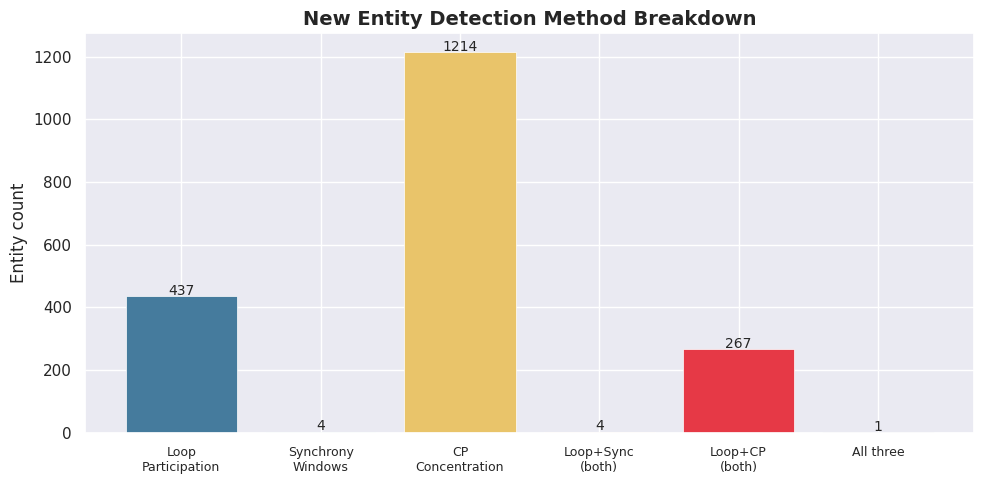

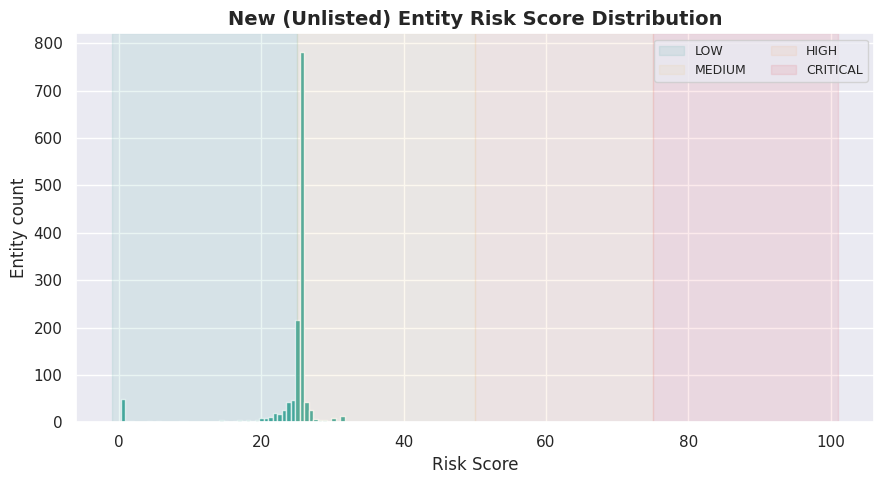

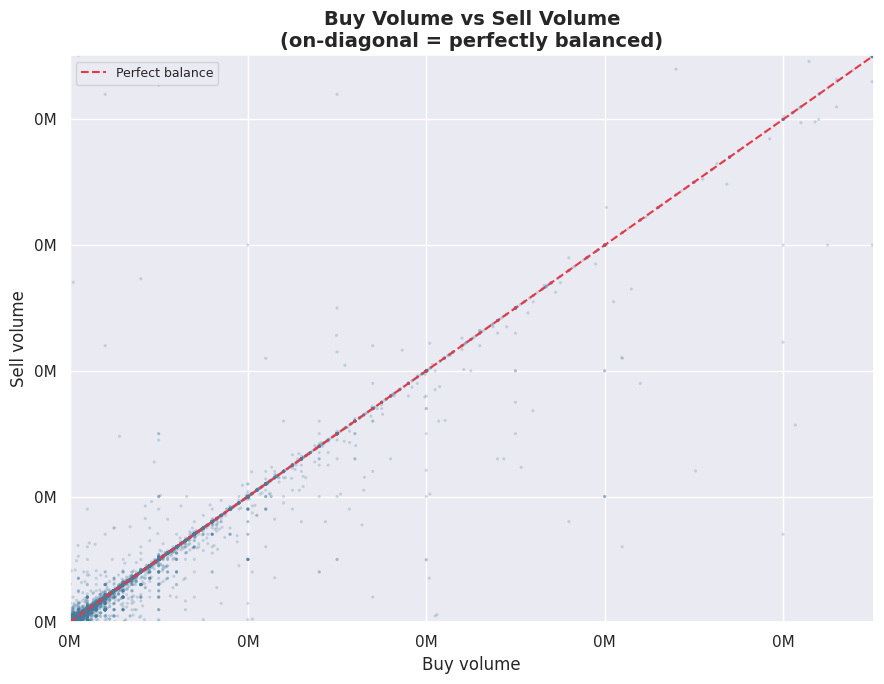

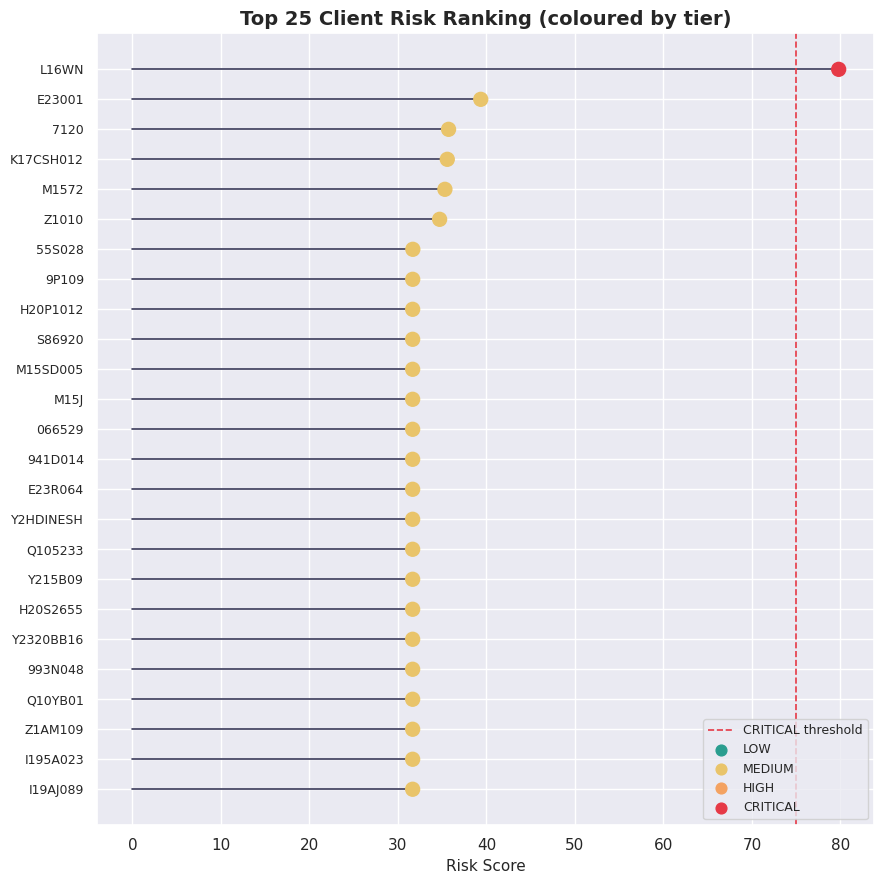


✔  27 charts saved to: E:\Synapse-BI\sentinel_charts
   01_heatmap_loops_scrip_date.png
   02_bar_L2_vs_L3.png
   03_donut_mechanism.png
   04_box_volume_by_mechanism.png
   05_scatter_timespan_vs_volume.png
   06_hist_avg_gap.png
   07_violin_volume_by_length.png
   08_bar_loops_by_date_scrip.png
   09_scatter_minleg_vs_total.png
   10_donut_validation_status.png
   11_hbar_confirmed_clients.png
   12_hist_client_risk_scores.png
   13_heatmap_signals_top25.png
   14_bar_evidence_strength.png
   15_scatter_reciprocity_vs_loops.png
   16_bar_client_risk_tiers.png
   17_bar_mean_signals_per_tier.png
   18_bubble_volume_vs_reciprocity.png
   19_hbar_members_by_clients.png
   20_bubble_member_signals.png
   21_bar_member_risk_tiers.png
   22_network_top40_participants.png
   23_bar_price_drift.png
   24_bar_new_entity_methods.png
   25_hist_new_entity_scores.png
   26_scatter_buy_vs_sell_volume.png
   27_dot_top25_risk_ranking.png


In [11]:
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = r'E:\Synapse-BI\sentinel_charts'
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')
PALETTE  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']
MECH_CLR = {'Pump & Dump': '#E63946', 'Infrastructure-Linked': '#457B9D',
            'Circular Trading': '#2A9D8F'}
TIER_CLR = {'LOW': '#2A9D8F', 'MEDIUM': '#E9C46A', 'HIGH': '#F4A261', 'CRITICAL': '#E63946'}
saved = []

def save(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    saved.append(name)

# ══════════════════════════════════════════════════════════════════════════════
# 01 — Heatmap: Loop Count per Scrip × Date
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
heat = (optimized_loops_df.groupby(['SCRIP_CODE', 'TRADE_DATE'])
        .size().reset_index(name='count')
        .pivot(index='SCRIP_CODE', columns='TRADE_DATE', values='count').fillna(0))
sns.heatmap(heat, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=.5, cbar_kws={'label': 'Loop count'})
ax.set_title('Loop Count: Scrip × Date', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Scrip'); ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); save('01_heatmap_loops_scrip_date.png')

# ══════════════════════════════════════════════════════════════════════════════
# 02 — Stacked Bar: L2 vs L3 Loops per Scrip-Date
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
grp = (optimized_loops_df.groupby(['SCRIP_CODE', 'TRADE_DATE', 'loop_length'])
       .size().reset_index(name='n'))
grp['label'] = grp['SCRIP_CODE'] + '\n' + grp['TRADE_DATE']
pivot = grp.pivot_table(index='label', columns='loop_length', values='n', fill_value=0)
pivot.columns = [f'L{c}' for c in pivot.columns]
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#457B9D', '#E63946'],
           edgecolor='white', linewidth=0.4)
ax.set_title('L2 vs L3 Loops per Scrip-Date', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Loop count'); ax.legend(title='Length', fontsize=9)
plt.tight_layout(); save('02_bar_L2_vs_L3.png')

# ══════════════════════════════════════════════════════════════════════════════
# 03 — Donut: Mechanism Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7))
mech_s = loops_full['mechanism'].value_counts()
wc2 = [MECH_CLR.get(m, '#888') for m in mech_s.index]
wedges, texts, autotexts = ax.pie(
    mech_s.values, labels=None, colors=wc2, autopct='%1.1f%%', startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax.legend(mech_s.index, loc='lower center', fontsize=10, ncol=1,
          bbox_to_anchor=(0.5, -0.15))
ax.set_title('Mechanism Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout(); save('03_donut_mechanism.png')

# ══════════════════════════════════════════════════════════════════════════════
# 04 — Box+Strip: Total Loop Volume by Mechanism (log)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
order = ['Pump & Dump', 'Infrastructure-Linked', 'Circular Trading']
sns.boxplot(data=loops_full, x='mechanism', y='total_volume', order=order,
            palette=MECH_CLR, ax=ax, showfliers=False, linewidth=1.2)
sns.stripplot(data=loops_full, x='mechanism', y='total_volume', order=order,
              palette=MECH_CLR, ax=ax, size=2.5, alpha=0.35, jitter=True)
ax.set_yscale('log')
ax.set_title('Total Loop Volume by Mechanism (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Total Volume (log)')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout(); save('04_box_volume_by_mechanism.png')

# ══════════════════════════════════════════════════════════════════════════════
# 05 — Scatter: Time Span vs Volume (log × log), coloured by mechanism
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for mech, gdf in loops_full.groupby('mechanism'):
    ax.scatter(gdf['time_span_sec'] / 3600, gdf['total_volume'],
               label=mech, color=MECH_CLR.get(mech, '#888'),
               alpha=0.45, s=18, edgecolors='none')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Time Span vs Volume (log × log)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time span (hours, log)'); ax.set_ylabel('Total volume (log)')
ax.legend(fontsize=9)
plt.tight_layout(); save('05_scatter_timespan_vs_volume.png')

# ══════════════════════════════════════════════════════════════════════════════
# 06 — Histogram: Avg Inter-Trade Gap Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
gap_data = loops_full['avg_gap_sec'].dropna()
ax.hist(gap_data / 3600, bins=50, color='#457B9D', edgecolor='white', alpha=0.85)
ax.axvline(gap_data.median() / 3600, color='#E63946', linewidth=2,
           linestyle='--', label=f'Median: {gap_data.median()/3600:.1f} h')
ax.set_title('Avg Inter-Trade Gap Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg gap (hours)'); ax.set_ylabel('Loop count'); ax.legend()
plt.tight_layout(); save('06_hist_avg_gap.png')

# ══════════════════════════════════════════════════════════════════════════════
# 07 — Violin: Volume Distribution by Loop Length (log)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=loops_full, x='loop_length', y='total_volume',
               palette=['#457B9D', '#E63946'], ax=ax, inner='quartile', linewidth=1.0)
ax.set_yscale('log')
ax.set_title('Volume Distribution by Loop Length (log)', fontsize=14, fontweight='bold')
ax.set_xlabel('Loop length'); ax.set_ylabel('Total volume (log)')
plt.tight_layout(); save('07_violin_volume_by_length.png')

# ══════════════════════════════════════════════════════════════════════════════
# 08 — Grouped Bar: Loop Count by Date & Scrip
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
date_scrip = (optimized_loops_df.groupby(['TRADE_DATE', 'SCRIP_CODE'])
              .size().reset_index(name='n'))
pivot2 = date_scrip.pivot(index='TRADE_DATE', columns='SCRIP_CODE', values='n').fillna(0)
pivot2.plot(kind='bar', ax=ax, color=['#2A9D8F', '#E63946'],
            edgecolor='white', linewidth=0.4)
ax.set_title('Loop Count by Date & Scrip', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Loop count'); ax.legend(title='Scrip', fontsize=9)
plt.tight_layout(); save('08_bar_loops_by_date_scrip.png')

# ══════════════════════════════════════════════════════════════════════════════
# 09 — Scatter: Min Leg Volume vs Total Volume (size = loop length)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
szmap = {2: 25, 3: 80}
for mech, gdf in loops_full.groupby('mechanism'):
    sz = gdf['loop_length'].map(szmap).fillna(40)
    ax.scatter(gdf['min_leg_volume'], gdf['total_volume'],
               c=MECH_CLR.get(mech, '#888'), s=sz, alpha=0.5,
               edgecolors='none', label=mech)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Min Leg Volume vs Total Volume\n(size = loop length)', fontsize=14, fontweight='bold')
ax.set_xlabel('Min leg volume (log)'); ax.set_ylabel('Total volume (log)')
ax.legend(fontsize=9)
plt.tight_layout(); save('09_scatter_minleg_vs_total.png')

# ══════════════════════════════════════════════════════════════════════════════
# 10 — Donut: Suspect Validation Status
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7))
vstatus = validation['validation_status'].value_counts()
vcolors = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A', 'INSUFFICIENT EVIDENCE': '#457B9D'}
wc3 = [vcolors.get(s, '#888') for s in vstatus.index]
wedges2, _, autotexts2 = ax.pie(
    vstatus.values, colors=wc3, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
for at in autotexts2: at.set_fontsize(12); at.set_fontweight('bold')
ax.legend(vstatus.index, loc='lower center', fontsize=10, bbox_to_anchor=(0.5, -0.15))
ax.set_title('Suspect Validation Status', fontsize=14, fontweight='bold')
plt.tight_layout(); save('10_donut_validation_status.png')

# ══════════════════════════════════════════════════════════════════════════════
# 11 — Horizontal Bar: Top 20 CONFIRMED Clients by Loop Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7))
top_confirmed = (validation[validation['validation_status'] == 'CONFIRMED']
                 .sort_values('loop_count', ascending=False).head(20))
cmap_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_confirmed)))
ax.barh(top_confirmed['client'][::-1], top_confirmed['loop_count'][::-1],
        color=cmap_bar, edgecolor='white', linewidth=0.3)
ax.set_title('Top 20 CONFIRMED — Loop Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Loop count')
ax.axvline(top_confirmed['loop_count'].median(), color='#264653',
           linestyle='--', linewidth=1.5, label='Median')
ax.legend(fontsize=9)
plt.tight_layout(); save('11_hbar_confirmed_clients.png')

# ══════════════════════════════════════════════════════════════════════════════
# 12 — Histogram: Client Risk Score Distribution with Tier Shading
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
scores = client_scores_final['Risk_Score'].dropna()
ax.hist(scores, bins=60, color='#457B9D', edgecolor='white', alpha=0.85)
tier_edges = [(-1,25,'#2A9D8F','LOW'),(25,50,'#E9C46A','MEDIUM'),
              (50,75,'#F4A261','HIGH'),(75,101,'#E63946','CRITICAL')]
for lo, hi, c, lbl in tier_edges:
    ax.axvspan(lo, hi, alpha=0.12, color=c, label=lbl)
ax.set_title('Client Risk Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Client count')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); save('12_hist_client_risk_scores.png')

# ══════════════════════════════════════════════════════════════════════════════
# 13 — Heatmap: Signal Matrix for Top 25 Clients
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
top25 = client_scores_final.head(25).set_index('client')[['S1','S2','S3','S4','S5']]
sns.heatmap(top25.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={'label': 'Signal strength (0–1)'})
ax.set_title('Signal Heatmap — Top 25 Clients', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); save('13_heatmap_signals_top25.png')

# ══════════════════════════════════════════════════════════════════════════════
# 14 — Bar: Evidence Strength Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
es = client_scores_final['Evidence_Strength'].value_counts().sort_index()
bar_es_c = ['#2A9D8F','#2A9D8F','#2A9D8F','#E9C46A','#F4A261','#E63946']
ax.bar(es.index, es.values,
       color=[bar_es_c[min(i, 5)] for i in es.index],
       edgecolor='white', linewidth=0.5)
ax.set_title('Evidence Strength Distribution (# signals ≥ 0.5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Signals firing'); ax.set_ylabel('Client count')
for i, v in zip(es.index, es.values):
    ax.text(i, v + 3, str(v), ha='center', fontsize=10)
plt.tight_layout(); save('14_bar_evidence_strength.png')

# ══════════════════════════════════════════════════════════════════════════════
# 15 — Scatter: Reciprocity Ratio vs Loop Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
cmap_val = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A', 'INSUFFICIENT EVIDENCE': '#457B9D'}
for status, gv in validation[validation['loop_count'] > 0].groupby('validation_status'):
    ax.scatter(gv['loop_count'], gv['reciprocity_ratio'],
               label=status, color=cmap_val.get(status, '#888'),
               alpha=0.5, s=20, edgecolors='none')
ax.set_xscale('log')
ax.axhline(0.8, color='#264653', linestyle='--', linewidth=1.5, label='Threshold 0.8')
ax.set_title('Reciprocity Ratio vs Loop Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Loop count (log)'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=9)
plt.tight_layout(); save('15_scatter_reciprocity_vs_loops.png')

# ══════════════════════════════════════════════════════════════════════════════
# 16 — Bar: Client Risk Tier Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
tier_counts = client_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, tier_counts.values,
       color=[TIER_CLR[t] for t in tier_order], edgecolor='white', linewidth=0.5)
ax.set_title('Client Risk Tier Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Client count')
for i, (t, v) in enumerate(zip(tier_order, tier_counts)):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); save('16_bar_client_risk_tiers.png')

# ══════════════════════════════════════════════════════════════════════════════
# 17 — Grouped Bar: Mean Signal Values per Risk Tier
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
signal_means = (client_scores_final
                .groupby('Risk_Tier')[['S1','S2','S3','S4','S5']].mean()
                .reindex(['LOW','MEDIUM','HIGH','CRITICAL']))
signal_means.T.plot(kind='bar', ax=ax,
                    color=[TIER_CLR[t] for t in ['LOW','MEDIUM','HIGH','CRITICAL']],
                    edgecolor='white', linewidth=0.4)
ax.set_title('Mean Signal Values per Risk Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Signal'); ax.set_ylabel('Mean signal value')
ax.set_ylim(0, 1.05); ax.legend(title='Risk Tier', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); save('17_bar_mean_signals_per_tier.png')

# ══════════════════════════════════════════════════════════════════════════════
# 18 — Bubble Scatter: Total Volume vs Reciprocity (bubble = loop count)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = validation[(validation['loop_count'] > 0) & (validation['total_volume'] > 0)].copy()
plot_df['sz'] = np.sqrt(plot_df['loop_count']) * 4
for status, gv in plot_df.groupby('validation_status'):
    ax.scatter(gv['total_volume'], gv['reciprocity_ratio'],
               s=gv['sz'], alpha=0.5,
               color=cmap_val.get(status, '#888'), edgecolors='none', label=status)
ax.set_xscale('log')
ax.set_title('Total Volume vs Reciprocity\n(bubble size = loop count)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total volume traded (log)'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=9)
plt.tight_layout(); save('18_bubble_volume_vs_reciprocity.png')

# ══════════════════════════════════════════════════════════════════════════════
# 19 — Horizontal Bar: Top 15 Members by Client Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))
top_mb = member_stats.head(15)
bar_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_mb)))
ax.barh(top_mb['member_code'].astype(str)[::-1],
        top_mb['client_count'][::-1],
        color=bar_c, edgecolor='white', linewidth=0.3)
ax.set_title('Top 15 Members by Client Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Unique clients served')
plt.tight_layout(); save('19_hbar_members_by_clients.png')

# ══════════════════════════════════════════════════════════════════════════════
# 20 — Bubble Scatter: Member Signal Space M1 vs M2 (bubble = M3)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
ms = member_scores_final.copy()
tier_c = [TIER_CLR.get(str(t), '#888') for t in ms['Risk_Tier']]
ax.scatter(ms['M1'], ms['M2'],
           s=(ms['M3'] * 300 + 10).clip(10, 300),
           c=tier_c, alpha=0.6, edgecolors='none')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.set_title('Member Signal Space  M1 vs M2\n(bubble size = volume signal M3)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('M1 — Loop-client involvement')
ax.set_ylabel('M2 — Client breadth')
ax.legend(title='Risk Tier', fontsize=9)
plt.tight_layout(); save('20_bubble_member_signals.png')

# ══════════════════════════════════════════════════════════════════════════════
# 21 — Bar: Member Risk Tier Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
m_tc = member_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, m_tc.values,
       color=[TIER_CLR[t] for t in tier_order], edgecolor='white', linewidth=0.5)
ax.set_title('Member Risk Tier Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Member count')
for i, (t, v) in enumerate(zip(tier_order, m_tc)):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); save('21_bar_member_risk_tiers.png')

# ══════════════════════════════════════════════════════════════════════════════
# 22 — Network Graph: Top 40 Loop Participants
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#0D1117')
fig.patch.set_facecolor('#0D1117')
top_nodes = loop_stats.sort_values('loop_count', ascending=False).head(40)['client'].tolist()
top_set   = set(top_nodes)
sub_edges = [(str(u), str(v)) for u, v in Client_DG.edges()
             if str(u) in top_set and str(v) in top_set]
H2 = nx.DiGraph()
H2.add_nodes_from(top_nodes)
H2.add_edges_from(sub_edges)
loop_count_map2 = loop_stats.set_index('client')['loop_count'].to_dict()
vstatus_map2    = validation.set_index('client')['validation_status'].to_dict()
nsizes  = [max(loop_count_map2.get(n, 1) * 0.04, 40) for n in H2.nodes()]
ncolors = [{'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A'}.get(
            vstatus_map2.get(n, ''), '#457B9D') for n in H2.nodes()]
pos2 = nx.spring_layout(H2, k=1.2, seed=42)
nx.draw_networkx(H2, pos2, ax=ax, node_size=nsizes, node_color=ncolors,
                 edge_color='#3A3A5A', arrows=True, arrowsize=8,
                 with_labels=True, font_size=6, font_color='white',
                 width=0.5, alpha=0.9)
legend_handles = [mpatches.Patch(color='#E63946', label='CONFIRMED'),
                  mpatches.Patch(color='#E9C46A', label='PARTIAL'),
                  mpatches.Patch(color='#457B9D', label='Other')]
ax.legend(handles=legend_handles, loc='upper left', fontsize=10,
          facecolor='#1A1A2E', labelcolor='white')
ax.set_title('Client Trade Network — Top 40 Loop Participants',
             fontsize=14, fontweight='bold', color='white')
ax.set_axis_off()
plt.tight_layout(); save('22_network_top40_participants.png')

# ══════════════════════════════════════════════════════════════════════════════
# 23 — Bar: Price Drift (%) per Scrip × Date
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
pp = price_pivot.copy()
pp['label'] = pp['SCRIP_CODE'] + '\n' + pp['TRADE_DATE']
bar_drift_c = ['#E63946' if v >= 0 else '#2A9D8F' for v in pp['price_drift_pct']]
ax.bar(pp['label'], pp['price_drift_pct'], color=bar_drift_c,
       edgecolor='white', linewidth=0.4)
ax.axhline(5,  color='#F4A261', linestyle='--', linewidth=1.5, label='+5% P&D threshold')
ax.axhline(-5, color='#F4A261', linestyle='--', linewidth=1.5)
ax.axhline(0,  color='white', linewidth=0.6)
ax.set_title('Price Drift (%) per Scrip × Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Price drift %'); ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
plt.tight_layout(); save('23_bar_price_drift.png')

# ══════════════════════════════════════════════════════════════════════════════
# 24 — Bar: New Entity Detection Method Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
method_counts = {
    'Loop\nParticipation': len(new_from_loops),
    'Synchrony\nWindows': len(sync_new),
    'CP\nConcentration': len(high_cp),
    'Loop+Sync\n(both)': len(new_from_loops & sync_new),
    'Loop+CP\n(both)': len(new_from_loops & high_cp),
    'All three': len(new_from_loops & sync_new & high_cp),
}
colors_m = ['#457B9D','#2A9D8F','#E9C46A','#F4A261','#E63946','#264653']
ax.bar(method_counts.keys(), method_counts.values(),
       color=colors_m, edgecolor='white', linewidth=0.5)
ax.set_title('New Entity Detection Method Breakdown', fontsize=14, fontweight='bold')
ax.set_ylabel('Entity count')
for i, (k, v) in enumerate(method_counts.items()):
    ax.text(i, v + 4, str(v), ha='center', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout(); save('24_bar_new_entity_methods.png')

# ══════════════════════════════════════════════════════════════════════════════
# 25 — Histogram: New (Unlisted) Entity Risk Score Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
new_scores = new_entities_final['Risk_Score'].dropna()
ax.hist(new_scores, bins=50, color='#2A9D8F', edgecolor='white', alpha=0.85)
for lo, hi, c, lbl in tier_edges:
    ax.axvspan(lo, hi, alpha=0.1, color=c, label=lbl)
ax.set_title('New (Unlisted) Entity Risk Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Entity count')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); save('25_hist_new_entity_scores.png')

# ══════════════════════════════════════════════════════════════════════════════
# 26 — Scatter: Buy Volume vs Sell Volume (balance cloud)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))
rd = recip_df[['buy_vol', 'sell_vol']].copy()
rd = rd[(rd['buy_vol'] > 0) & (rd['sell_vol'] > 0)]
ax.scatter(rd['buy_vol'], rd['sell_vol'],
           alpha=0.25, s=5, color='#457B9D', edgecolors='none')
lim_max = max(rd['buy_vol'].quantile(0.99), rd['sell_vol'].quantile(0.99))
ax.plot([0, lim_max], [0, lim_max], color='#E63946', linewidth=1.5,
        linestyle='--', label='Perfect balance')
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_title('Buy Volume vs Sell Volume\n(on-diagonal = perfectly balanced)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Buy volume'); ax.set_ylabel('Sell volume')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(fontsize=9)
plt.tight_layout(); save('26_scatter_buy_vs_sell_volume.png')

# ══════════════════════════════════════════════════════════════════════════════
# 27 — Ranked Dot Plot: Top 25 Client Risk Ranking
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 9))
top25_risk = client_scores_final.head(25).reset_index(drop=True)
dot_c = [TIER_CLR.get(str(t), '#888') for t in top25_risk['Risk_Tier']]
ax.scatter(top25_risk['Risk_Score'],
           range(len(top25_risk))[::-1],
           c=dot_c, s=100, zorder=3)
for i, row in top25_risk.iterrows():
    ax.plot([0, row['Risk_Score']], [len(top25_risk)-1-i]*2,
            color='#3A3A5A', linewidth=1.2, zorder=2)
ax.set_yticks(range(len(top25_risk)))
ax.set_yticklabels(top25_risk['client'][::-1], fontsize=9)
ax.set_xlabel('Risk Score', fontsize=11)
ax.set_title('Top 25 Client Risk Ranking (coloured by tier)',
             fontsize=14, fontweight='bold')
ax.axvline(75, color='#E63946', linestyle='--', linewidth=1.2, label='CRITICAL threshold')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.legend(fontsize=9)
plt.tight_layout(); save('27_dot_top25_risk_ranking.png')

# ══════════════════════════════════════════════════════════════════════════════
print(f"\n✔  {len(saved)} charts saved to: {OUT_DIR}")
for n in saved:
    print(f"   {n}")